# Explaining Depth Anything V2 with 5 XAI Methods, including TCAV

Name: Efe GÜRDAMAR Student Number: 2220356100

Name: Hüseyin KÖROĞLU Student Number: 2220356069



This notebook has one job: explain **why Depth Anything V2 predicts a depth map the way it does**.

Latest update: **TCAV semantic concept attribution** was added between Attention Rollout and Integrated Gradients, so the project now combines transformer attention, concept directions, gradients, decoder CAM, and perturbation evidence.

The notebook intentionally uses five explanation views in the main result:

| Method | Why it is used | What it answers |
|---|---|---|
| Attention Rollout | Depth Anything V2 has a ViT encoder | Which image regions are important in transformer-level scene reasoning? |
| TCAV-style CAV projection | Semantic concepts reveal learned representations | Do depth-specific concepts (edges, flat regions, slopes) align with encoder features? |
| Integrated Gradients | Dense depth output needs pixel-level attribution | Which input pixels most affect the depth target? |
| Grad-CAM++ Decoder | Depth is produced by spatial decoder features | Do decoder activations point to similar regions as the other explanations? |
| Occlusion Sensitivity | Perturbation-based control | Does hiding a region actually change the depth prediction? |


Model: **Depth Anything V2 Large / ViT-L**  
Dataset: **NYU Depth V2**  
Task: **dense monocular depth regression**

## 1. Setup

This section prepares the Colab environment: GPU check, package installation, imports, output folders, and random seeds. There is no XAI result here yet; it only makes the rest of the notebook reproducible.


In [1]:
# [Notebook Cell]
# Install DAV2 dependencies and clone the reference repo so Colab can import the model code.
!pip install -q torch torchvision timm transformers opencv-python Pillow matplotlib tqdm scipy h5py grad-cam scikit-image pandas
!rm -rf /content/Depth-Anything-V2
!git clone -q https://github.com/DepthAnything/Depth-Anything-V2.git /content/Depth-Anything-V2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 39.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
# [Notebook Cell]
# Centralized imports and deterministic seeds keep XAI comparisons reproducible across methods.
import os, sys, json, math, random, types, shutil, urllib.request, gc, time, platform, zipfile
from datetime import datetime, timezone
from pathlib import Path

import cv2
import h5py
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from torchvision import transforms
from scipy.stats import spearmanr, pearsonr
from skimage import feature, filters
from sklearn.linear_model import LogisticRegression

sys.path.append('/content/Depth-Anything-V2')
from depth_anything_v2.dpt import DepthAnythingV2

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
RUN_STARTED_AT = time.time()

for p in ['data', 'outputs/xai', 'outputs/tables', 'outputs/curves', 'outputs/checkpoints']:
    Path(p).mkdir(parents=True, exist_ok=True)

print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())
print('Device:', DEVICE)

PyTorch: 2.11.0+cu128
CUDA: True
Device: cuda


## 2. Configuration

These settings control model size, image resolution, sample count, and XAI runtime. Dense depth explanations are expensive because the model predicts a full image, so the defaults are kept small enough for a Colab GPU.

Start with the default `NUM_XAI_SAMPLES`, `IG_STEPS`, and occlusion stride. After one successful run, they can be increased for cleaner but slower explanations.


In [3]:
# [Notebook Cell]
# Runtime knobs balance explanation fidelity with Colab memory limits for dense 518×518 maps.
MODEL_ENCODER = 'vitl'
INPUT_SIZE = 518
PATCH_SIZE = 14
DEPTH_MIN, DEPTH_MAX = 1e-3, 10.0

EVAL_SCAN_LIMIT = 500
NUM_GOOD = 3
NUM_BAD = 3
NUM_RANDOM = 6
NUM_XAI_SAMPLES = NUM_GOOD + NUM_BAD + NUM_RANDOM

IG_STEPS = 16
OCCLUSION_PATCH = 74
OCCLUSION_STRIDE = 74
PERTURBATION_FRACTIONS = [0.02, 0.05, 0.10, 0.20, 0.30]

RUN_RANDOMIZATION_SANITY = True
SANITY_METHODS = ['integrated_gradients', 'gradcampp_decoder']
RANDOMIZATION_LEVELS = ['decoder', 'encoder_last4', 'full']

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)

MODEL_CONFIGS = {
    'vits': {'encoder': 'vits', 'features': 64,  'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]},
}
CHECKPOINT_URLS = {
    'vits': 'https://huggingface.co/depth-anything/Depth-Anything-V2-Small/resolve/main/depth_anything_v2_vits.pth',
    'vitb': 'https://huggingface.co/depth-anything/Depth-Anything-V2-Base/resolve/main/depth_anything_v2_vitb.pth',
    'vitl': 'https://huggingface.co/depth-anything/Depth-Anything-V2-Large/resolve/main/depth_anything_v2_vitl.pth',
}

assert MODEL_ENCODER in MODEL_CONFIGS
print('Configured model:', MODEL_ENCODER)

Configured model: vits


## 3. Dataset: NYU Depth V2

NYU Depth V2 gives RGB images with ground-truth depth maps. This lets us evaluate not only the depth prediction, but also whether XAI maps line up with real depth boundaries.

Depth Anything V2 predicts relative depth. For metric tables, each prediction is aligned to the ground truth with a per-image scale and shift. The XAI maps are still computed from the model's own prediction behavior.

Expected result from this section: loaded RGB/depth pairs ready for prediction and explanation.


In [4]:
# [Notebook Cell]
# NYU Depth V2 provides GT geometry, enabling attribution checks beyond RGB saliency.
MAT_URL = 'http://horatio.cs.nyu.edu/mit/silberman/nyu_depth_v2/nyu_depth_v2_labeled.mat'
MAT_PATH = Path('data/nyu_depth_v2_labeled.mat')
DATA_DIR = Path('data/nyu_depth_v2')
IMG_DIR = DATA_DIR / 'images'
DEP_DIR = DATA_DIR / 'depths'

if not MAT_PATH.exists():
    print('Downloading NYU Depth V2 labeled subset, about 2.8 GB ...')
    def _progress(blocks, block_size, total_size):
        """Report download progress for large dataset files so long Colab downloads remain observable.
        """
        done = blocks * block_size
        pct = 100 * done / max(total_size, 1)
        print(f'\r{pct:5.1f}% {done/1e9:.2f}/{total_size/1e9:.2f} GB', end='', flush=True)
    urllib.request.urlretrieve(MAT_URL, MAT_PATH, _progress)
    print('\nDownload complete.')
else:
    print('NYU MAT file exists.')

IMG_DIR.mkdir(parents=True, exist_ok=True)
DEP_DIR.mkdir(parents=True, exist_ok=True)

if len(list(IMG_DIR.glob('*.png'))) < 1449 or len(list(DEP_DIR.glob('*.npy'))) < 1449:
    print('Extracting NYU RGB/depth pairs ...')
    with h5py.File(MAT_PATH, 'r') as f:
        images, depths = f['images'], f['depths']
        for i in tqdm(range(images.shape[0]), desc='extract'):
            rgb = np.transpose(images[i], (2, 1, 0))
            dep = np.transpose(depths[i], (1, 0)).astype(np.float32)
            Image.fromarray(rgb.astype(np.uint8)).save(IMG_DIR / f'{i:04d}.png')
            np.save(DEP_DIR / f'{i:04d}.npy', dep)
else:
    print('NYU extraction exists.')

TRAIN_IDXS = list(range(0, 795))
TEST_IDXS = list(range(795, 1449))
manifest = {
    'train': [{'id': i, 'image': f'nyu_depth_v2/images/{i:04d}.png', 'depth': f'nyu_depth_v2/depths/{i:04d}.npy'} for i in TRAIN_IDXS],
    'test': [{'id': i, 'image': f'nyu_depth_v2/images/{i:04d}.png', 'depth': f'nyu_depth_v2/depths/{i:04d}.npy'} for i in TEST_IDXS],
}
print(f"Split metadata: {len(manifest['train'])} train / {len(manifest['test'])} test")

100.0% 2.97/2.97 GB
Download complete.
Extracting NYU RGB/depth pairs ...


extract:   0%|          | 0/1449 [00:00<?, ?it/s]

Split metadata: 795 train / 654 test


In [5]:
# [Notebook Cell]
# Shared preprocessing keeps model inputs, depth maps, and XAI overlays on the same spatial frame.
def load_pair(pair):
    """Load one RGB/depth pair from the manifest and clamp depth to the valid evaluation range."""
    image = Image.open('data/' + pair['image']).convert('RGB')
    depth = np.load('data/' + pair['depth']).astype(np.float32)
    depth = np.clip(depth, DEPTH_MIN, DEPTH_MAX)
    return image, depth

def preprocess_pil(image_pil, size=INPUT_SIZE):
    """Resize and ImageNet-normalize a PIL image into the tensor format expected by Depth Anything V2.
    """
    tf = transforms.Compose([
        transforms.Resize((size, size), antialias=True),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    return tf(image_pil).unsqueeze(0)

def resize_np(arr, size=INPUT_SIZE, interpolation=cv2.INTER_NEAREST):
    """Resize numpy depth or heatmap arrays to the shared notebook resolution for fair comparison.
    """
    return cv2.resize(arr, (size, size), interpolation=interpolation).astype(np.float32)

def denormalize_tensor(x):
    """Convert normalized model input back to [0, 1] image space for baselines and visualization.
    """
    return (x * IMAGENET_STD.to(x.device) + IMAGENET_MEAN.to(x.device)).clamp(0, 1)

def normalize_tensor(x01):
    """Apply ImageNet normalization after perturbation or baseline generation."""
    return (x01 - IMAGENET_MEAN.to(x01.device)) / IMAGENET_STD.to(x01.device)

img0, dep0 = load_pair(manifest['test'][0])
print('Sample image:', img0.size, '| depth:', dep0.shape, dep0.min(), dep0.max())

Sample image: (640, 480) | depth: (480, 640) 1.6132504 8.586743


## 4. Load Depth Anything V2

This loads the Depth Anything V2 ViT-L checkpoint. The architecture matters for the XAI choices: the ViT encoder makes Attention Rollout meaningful, while the spatial decoder gives a place to test Grad-CAM++ for dense prediction.

After this cell, the model should be on the selected device and ready for inference.


In [6]:
# [Notebook Cell]
# Loading the published checkpoint preserves pretrained depth priors before attribution begins.
def download_checkpoint(encoder):
    """Fetch the requested Depth Anything V2 checkpoint once and reuse the cached local copy."""
    ckpt_path = Path(f'outputs/checkpoints/depth_anything_v2_{encoder}.pth')
    if ckpt_path.exists():
        print('Checkpoint exists:', ckpt_path)
        return ckpt_path
    url = CHECKPOINT_URLS[encoder]
    print('Downloading checkpoint:', url)
    urllib.request.urlretrieve(url, ckpt_path)
    print('Saved:', ckpt_path)
    return ckpt_path

# Download pre-trained weights from HuggingFace; avoids retraining while preserving the published DAV2 prior.
ckpt_path = download_checkpoint(MODEL_ENCODER)
model = DepthAnythingV2(**MODEL_CONFIGS[MODEL_ENCODER])
model.load_state_dict(torch.load(ckpt_path, map_location='cpu'))
model = model.to(DEVICE).eval()
model_parameters = sum(p.numel() for p in model.parameters())
print(f'Depth Anything V2 {MODEL_ENCODER}: {model_parameters/1e6:.1f}M parameters')

gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
gpu_memory_gb = (torch.cuda.get_device_properties(0).total_memory / 1024**3) if torch.cuda.is_available() else 0.0
run_environment = {
    'timestamp_utc': datetime.now(timezone.utc).isoformat(),
    'python_version': platform.python_version(),
    'pytorch_version': torch.__version__,
    'cuda_version': torch.version.cuda,
    'device': str(DEVICE),
    'gpu_name': gpu_name,
    'gpu_memory_gb': round(gpu_memory_gb, 2),
    'model_encoder': MODEL_ENCODER,
    'model_parameters': model_parameters,
    'input_size': INPUT_SIZE,
    'eval_scan_limit': EVAL_SCAN_LIMIT,
    'num_good': NUM_GOOD,
    'num_bad': NUM_BAD,
    'num_random': NUM_RANDOM,
    'ig_steps': IG_STEPS,
    'occlusion_patch': OCCLUSION_PATCH,
    'occlusion_stride': OCCLUSION_STRIDE,
    'seed': SEED,
}
with open('outputs/tables/run_environment.json', 'w') as f:
    json.dump(run_environment, f, indent=2)
print(f'GPU: {gpu_name} ({gpu_memory_gb:.1f} GB)')
print('Saved: outputs/tables/run_environment.json')

Saved: outputs/checkpoints/depth_anything_v2_vits.pth
Depth Anything V2 vits: 24.8M parameters


## 5. Prediction Quality: Select Good and Bad Examples

Before explaining the model, the notebook first finds examples where the model performs well and examples where it fails. This avoids explaining only easy cases.

The table uses standard depth metrics: `rmse`, `mae`, and `abs_rel` should be low; `d1`, `d2`, and `d3` should be high. The selected samples from both ends are used for the XAI comparisons later.


In [7]:
# [Notebook Cell]
# Prediction utilities align relative DAV2 depth to GT so metrics are comparable per image.
@torch.no_grad()
def predict_depth(image_tensor, active_model=None):
    """Run dense depth inference and normalize output shape to a batch of 2D depth maps."""
    active_model = active_model or model
    pred = active_model(image_tensor.to(DEVICE))
    if pred.ndim == 4:
        pred = pred.squeeze(1)
    return pred

def align_depth_least_squares(pred, gt, mask=None):
    """Align relative predicted depth to metric ground truth with per-image scale and shift."""
    pred = np.asarray(pred, dtype=np.float32)
    gt = np.asarray(gt, dtype=np.float32)
    if mask is None:
        mask = np.isfinite(gt) & (gt > DEPTH_MIN)
    p, t = pred[mask].reshape(-1), gt[mask].reshape(-1)
    if len(p) < 2 or np.std(p) < 1e-8:
        return pred.copy(), 1.0, 0.0
    A = np.stack([p, np.ones_like(p)], axis=1)
    scale, shift = np.linalg.lstsq(A, t, rcond=None)[0]
    return (pred * scale + shift).astype(np.float32), float(scale), float(shift)

def depth_metrics(pred_aligned, gt, eps=1e-6):
    """Compute standard monocular depth quality metrics on valid ground-truth pixels."""
    mask = np.isfinite(gt) & (gt > DEPTH_MIN)
    p = np.clip(pred_aligned[mask], eps, None)
    t = np.clip(gt[mask], eps, None)
    thr = np.maximum(p / t, t / p)
    return {
        'abs_rel': float(np.mean(np.abs(p - t) / t)),
        'rmse': float(np.sqrt(np.mean((p - t) ** 2))),
        'mae': float(np.mean(np.abs(p - t))),
        'd1': float(np.mean(thr < 1.25)),
        'd2': float(np.mean(thr < 1.25 ** 2)),
        'd3': float(np.mean(thr < 1.25 ** 3)),
    }

def predict_pair(pair, active_model=None):
    """Run the full prediction pipeline for one sample and package depth, error, and metadata."""
    image_pil, gt = load_pair(pair)
    x = preprocess_pil(image_pil).to(DEVICE)
    with torch.no_grad():
        pred = predict_depth(x, active_model=active_model)[0].detach().cpu().numpy()
    gt_r = resize_np(gt, INPUT_SIZE, cv2.INTER_NEAREST)
    aligned, scale, shift = align_depth_least_squares(pred, gt_r)
    error = np.abs(aligned - gt_r)
    return {
        'pair': pair, 'image_pil': image_pil, 'x': x, 'pred': pred,
        'gt': gt_r, 'aligned': aligned, 'error': error,
        'scale': scale, 'shift': shift, 'metrics': depth_metrics(aligned, gt_r),
    }

probe = predict_pair(manifest['test'][0])
print(probe['metrics'])

{'abs_rel': 0.17378371953964233, 'rmse': 0.9604713916778564, 'mae': 0.6271553039550781, 'd1': 0.773031857008691, 'd2': 0.9673454480404288, 'd3': 0.9772886510338248}


In [8]:
# [Notebook Cell]
# Selecting both low- and high-error samples prevents XAI evaluation from only covering easy cases.
scan_rows = []
for pair in tqdm(manifest['test'][:EVAL_SCAN_LIMIT], desc='scan test predictions'):
    item = predict_pair(pair)
    scan_rows.append({'id': pair['id'], **item['metrics']})
scan_df = pd.DataFrame(scan_rows).sort_values('rmse').reset_index(drop=True)
scan_df.to_csv('outputs/tables/prediction_scan.csv', index=False)

good_ids = scan_df.head(NUM_GOOD)['id'].tolist()
bad_ids = scan_df.tail(NUM_BAD)['id'].tolist()
remaining = [p['id'] for p in manifest['test'][:EVAL_SCAN_LIMIT] if p['id'] not in set(good_ids + bad_ids)]
random_ids = random.sample(remaining, k=min(NUM_RANDOM, len(remaining))) if NUM_RANDOM else []
selected_ids = good_ids + bad_ids + random_ids
selected_pairs = [p for p in manifest['test'] if p['id'] in set(selected_ids)]
selected_pairs = sorted(selected_pairs, key=lambda p: selected_ids.index(p['id']))
selection_group_by_id = {**{i: 'good' for i in good_ids}, **{i: 'bad' for i in bad_ids}, **{i: 'random' for i in random_ids}}
selected_scan_df = scan_df[scan_df['id'].isin(selected_ids)].copy()
selected_scan_df['selection_group'] = selected_scan_df['id'].map(selection_group_by_id)
selected_scan_df['selection_order'] = selected_scan_df['id'].map({sample_id: order for order, sample_id in enumerate(selected_ids)})
selected_scan_df = selected_scan_df.sort_values('selection_order')
selected_scan_df.to_csv('outputs/tables/sample_selection.csv', index=False)

print('Good examples:', good_ids)
print('Bad examples:', bad_ids)
print('Selected examples:', selected_ids)
display(scan_df.head(8))
display(scan_df.tail(8))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metric_specs = [('rmse', 'RMSE (lower is better)'), ('abs_rel', 'AbsRel (lower is better)'), ('d1', 'delta1 (higher is better)')]
group_colors = {'good': 'seagreen', 'random': 'royalblue', 'bad': 'crimson'}
for ax, (metric, label) in zip(axes, metric_specs):
    ax.hist(scan_df[metric], bins=30, color='lightgray', edgecolor='white')
    ymax = ax.get_ylim()[1]
    for group, ids in [('good', good_ids), ('random', random_ids), ('bad', bad_ids)]:
        values = scan_df.loc[scan_df['id'].isin(ids), metric]
        ax.scatter(values, np.full(len(values), ymax * 0.04), color=group_colors[group], label=group, s=28, zorder=3)
    ax.set_xlabel(label)
    ax.set_ylabel('Test-image count')
    ax.grid(axis='y', alpha=0.2)
axes[0].legend()
fig.suptitle('Prediction-quality distribution over scanned NYU Depth V2 test images')
plt.tight_layout()
plt.savefig('outputs/curves/prediction_quality_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

scan test predictions:   0%|          | 0/500 [00:00<?, ?it/s]

Good examples: [873, 867, 1068]
Bad examples: [1245, 893, 800]
Selected examples: [873, 867, 1068, 1245, 893, 800]


,id,abs_rel,rmse,mae,d1,d2,d3
0,873,0.036999,0.076202,0.047539,0.989226,0.996105,0.998822
1,867,0.046794,0.119349,0.091891,0.980829,1.000000,1.000000
2,1068,0.039302,0.130370,0.077553,0.984932,0.994693,1.000000
3,1052,0.060077,0.136785,0.096871,0.974341,0.991000,0.995804
4,870,0.047571,0.153132,0.094568,0.988134,0.993694,1.000000
5,1125,0.059612,0.159404,0.116047,0.983874,0.990586,0.996650
6,845,0.105284,0.159987,0.128889,0.940371,0.971803,0.980557
7,1163,0.074123,0.169385,0.122364,0.975753,0.990217,0.991369


,id,abs_rel,rmse,mae,d1,d2,d3
492,1241,0.215059,1.260263,0.873497,0.654645,0.913515,0.988190
493,1237,0.308611,1.273428,1.047313,0.445011,0.876515,0.924848
494,798,0.283698,1.355611,1.013321,0.445752,0.844602,0.940687
495,1277,0.388860,1.375473,1.142408,0.401984,0.704931,0.846909
496,1240,0.249335,1.400193,1.087308,0.514792,0.950057,0.965094
497,1245,0.286278,1.458649,1.142831,0.361231,0.935209,0.956180
498,893,0.449746,1.535428,1.232572,0.302470,0.552768,0.866512
499,800,0.358547,1.563095,1.245017,0.312290,0.787846,0.892455


## 6. Visualization Helpers

These helper functions normalize depth maps, errors, and heatmaps into comparable images. They also create overlays and two-panel figures.

The important point is consistency: every method is visualized with the same normalization and the same RGB alignment, so pairwise comparisons are easier to read.


In [9]:
# [Notebook Cell]
# Visualization helpers enforce identical normalization so heatmaps are visually comparable.
def normalize_map(a, q_low=1, q_high=99):
    """Robustly normalize attribution, depth, or error arrays while suppressing percentile outliers.
    """
    a = np.nan_to_num(np.asarray(a, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    lo, hi = np.percentile(a, [q_low, q_high])
    if hi - lo < 1e-8:
        lo, hi = float(a.min()), float(a.max())
    return np.clip((a - lo) / (hi - lo + 1e-8), 0, 1)

def colorize_depth(depth, cmap='inferno'):
    """Map normalized depth values to RGB colors for visual inspection."""
    return (plt.get_cmap(cmap)(normalize_map(depth))[:, :, :3] * 255).astype(np.uint8)

def colorize_heatmap(hm, cmap='jet'):
    """Map normalized saliency values to RGB colors using a heatmap colormap."""
    return (plt.get_cmap(cmap)(normalize_map(hm))[:, :, :3] * 255).astype(np.uint8)

def overlay_heatmap(image_pil_or_np, heatmap, alpha=0.45, cmap='jet'):
    """Blend a heatmap onto RGB so attribution can be judged in image coordinates."""
    if isinstance(image_pil_or_np, Image.Image):
        rgb = np.array(image_pil_or_np.resize((INPUT_SIZE, INPUT_SIZE)))
    else:
        rgb = np.asarray(image_pil_or_np)
        if rgb.shape[:2] != heatmap.shape[:2]:
            rgb = cv2.resize(rgb, (heatmap.shape[1], heatmap.shape[0]), interpolation=cv2.INTER_AREA)
    heat = colorize_heatmap(heatmap, cmap=cmap)
    return (alpha * heat + (1 - alpha) * rgb).astype(np.uint8)

def plot_grid(images, titles, path=None, cols=6, figsize=(22, 8), show=True):
    """Render a compact grid of comparison images and optionally save it for the report."""
    n = len(images)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img)
        ax.set_title(title, fontsize=9)
        ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    plt.tight_layout()
    if path:
        plt.savefig(path, dpi=140, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close(fig)

def save_pair_figure(left_img, right_img, left_title, right_title, path):
    # Pairwise figures keep each comparison tied to one question.
    """Save a two-panel comparison focused on one diagnostic question."""
    plot_grid([left_img, right_img], [left_title, right_title], path=path, cols=2, figsize=(8, 4), show=False)


## 7. XAI Target for Dense Depth Regression

Classification XAI usually explains one class score. Depth estimation has no class score; it outputs a depth value at every pixel.

To use attribution methods here, the notebook defines a scalar target from the depth map. The default target is the global mean predicted depth. The explanations therefore answer:

**Which input regions most affect this scalar summary of the dense depth prediction?**


In [10]:
# [Notebook Cell]
# Dense depth needs a scalar objective; this target converts pixelwise output into an attribution score.
class DenseDepthTarget:
    """Represent a scalar objective extracted from dense depth output for attribution methods."""
    def __init__(self, mode='global_mean', bbox=None, mask=None):
        """Store target configuration without touching model tensors so targets stay lightweight."""
        self.mode = mode
        self.bbox = bbox
        self.mask = mask

    def tensor_target(self, pred):
        """Convert dense predictions into a scalar score using global, box, or mask averaging."""
        if pred.ndim == 2:
            d = pred.unsqueeze(0)
        elif pred.ndim == 3:
            d = pred
        elif pred.ndim == 4:
            d = pred.squeeze(1)
        else:
            raise ValueError(f'Unexpected prediction shape: {tuple(pred.shape)}')
        if self.mode == 'global_mean':
            return d.mean(dim=(-2, -1))
        if self.mode == 'bbox_mean':
            y0, x0, y1, x1 = self.bbox
            return d[:, y0:y1, x0:x1].mean(dim=(-2, -1))
        if self.mode == 'mask_mean':
            mask = self.mask.to(d.device).float()
            if mask.ndim == 2:
                mask = mask.unsqueeze(0)
            return (d * mask).sum(dim=(-2, -1)) / mask.sum(dim=(-2, -1)).clamp_min(1)
        raise ValueError(self.mode)

    def __call__(self, model_output):
        """Expose the target with the callable interface expected by attribution libraries."""
        return self.tensor_target(model_output)

## 8. XAI Method 1: Attention Rollout

Attention Rollout is the transformer-specific explanation. It combines attention matrices across ViT blocks to estimate which image patches influence the final representation used for depth prediction.

This method is mainly used for global scene reasoning: perspective, layout, large structural boundaries, and depth-related context. It is not treated as causal by itself, so later sections compare it with depth edges, error maps, and perturbation results.

In the pairwise figures, check whether Attention Rollout highlights depth structure or only visually salient texture.


In [11]:
# [XAI Method Implementation]
# Attention Rollout: aggregates ViT self-attention across transformer blocks to expose global token routing.
def patch_attention_modules_for_capture(active_model):
    """Patch ViT attention blocks so rollout can access self-attention matrices after inference.
    """
    patched = []
    for name, module in active_model.named_modules():
        if hasattr(module, 'qkv') and hasattr(module, 'num_heads') and hasattr(module, 'proj'):
            if hasattr(module, '_xai_original_forward'):
                continue
            module._xai_original_forward = module.forward
            def forward_with_capture(self, x, _name=name):
                """Mirror the original attention forward pass while retaining the softmax attention tensor."""
                B, N, C = x.shape
                qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
                q, k, v = qkv[0], qkv[1], qkv[2]
                scale = getattr(self, 'scale', q.shape[-1] ** -0.5)
                attn = (q @ k.transpose(-2, -1)) * scale
                attn = attn.softmax(dim=-1)
                self.last_attn = attn.detach()
                attn_used = self.attn_drop(attn) if hasattr(self, 'attn_drop') else attn
                out = (attn_used @ v).transpose(1, 2).reshape(B, N, C)
                out = self.proj(out)
                if hasattr(self, 'proj_drop'):
                    out = self.proj_drop(out)
                return out
            module.forward = types.MethodType(forward_with_capture, module)
            patched.append(name)
    print(f'Patched {len(patched)} attention modules')
    return patched

def collect_attention_matrices(active_model):
    """Collect cached attention tensors from all patched transformer modules."""
    return [m.last_attn for m in active_model.modules() if hasattr(m, 'last_attn')]

def attention_rollout_map(active_model, image_tensor):
    """Propagate attention through transformer blocks and upsample patch relevance to image resolution.
    """
    patch_attention_modules_for_capture(active_model)
    active_model.eval()
    with torch.no_grad():
        _ = active_model(image_tensor.to(DEVICE))
    attns = collect_attention_matrices(active_model)
    if not attns:
        raise RuntimeError('No attention matrices captured.')
    result = None
    for attn in attns:
        a = attn[0].mean(dim=0)
        eye = torch.eye(a.shape[-1], device=a.device)
        a = a + eye
        a = a / a.sum(dim=-1, keepdim=True).clamp_min(1e-8)
        result = a if result is None else a @ result
    num_patch_tokens = (INPUT_SIZE // PATCH_SIZE) * (INPUT_SIZE // PATCH_SIZE)
    patch_relevance = result[-num_patch_tokens:, -num_patch_tokens:].mean(dim=0)
    side = int(math.sqrt(num_patch_tokens))
    hm = patch_relevance.reshape(1, 1, side, side)
    hm = F.interpolate(hm, size=(INPUT_SIZE, INPUT_SIZE), mode='bilinear', align_corners=False)
    return normalize_map(hm[0, 0].detach().cpu().numpy())

## 9. XAI Method 2: TCAV-style CAV Semantic Concept Projection

This TCAV-style method learns concept activation vectors from ViT encoder activations using depth-derived positives and negatives. The vectors are projected patch-wise to produce 518×518 semantic heatmaps; it is a spatial CAV projection rather than the standard TCAV directional-derivative score.


In [12]:
# [XAI Method Implementation]
# TCAV: semantic concepts (depth edges, flat regions, slopes) represented as directions in ViT activation space.
TCAV_LAYER_NAME = {'vits': 'blocks.11', 'vitb': 'blocks.11', 'vitl': 'blocks.23'}[MODEL_ENCODER]
TCAV_MAX_CANDIDATES = 48
TCAV_SAMPLES_PER_CLASS = 6
TCAV_CONCEPT_VECTORS = None
TCAV_CLASSIFIERS = None


def _resolve_vit_block(active_model: nn.Module, layer_name: str = TCAV_LAYER_NAME) -> nn.Module:
    """Resolve a ViT encoder block from Depth Anything V2 using notebook-friendly layer aliases."""
    normalized_name = layer_name.replace('_', '.')
    blocks = getattr(getattr(active_model, 'pretrained', None), 'blocks', None)
    if blocks is not None and normalized_name.startswith('blocks.'):
        block_index = int(normalized_name.split('.')[-1])
        return blocks[block_index]
    for module_name, module in active_model.named_modules():
        if module_name == normalized_name:
            return module
    raise ValueError(f'Could not resolve TCAV layer: {layer_name}')


def _patch_tokens_from_activation(activation: torch.Tensor) -> torch.Tensor:
    """Keep only spatial patch tokens so TCAV maps align with the 37×37 ViT grid for 518×518 input."""
    if isinstance(activation, (tuple, list)):
        activation = activation[0]
    if activation.ndim != 3:
        raise ValueError(f'Expected token activation (B, N, C), got {tuple(activation.shape)}')
    num_patch_tokens = (INPUT_SIZE // PATCH_SIZE) * (INPUT_SIZE // PATCH_SIZE)
    tokens = activation[:, -num_patch_tokens:, :] if activation.shape[1] >= num_patch_tokens else activation
    return F.normalize(tokens.detach(), p=2, dim=-1)


def extract_encoder_activations(
    active_model: nn.Module,
    image_tensor: torch.Tensor,
    layer_name: str = TCAV_LAYER_NAME,
) -> torch.Tensor:
    """Extract normalized ViT encoder patch activations for TCAV.

    Args:
        active_model: Depth Anything V2 model with a ViT encoder.
        image_tensor: Normalized image tensor shaped (1, 3, 518, 518).
        layer_name: ViT block alias such as ``blocks.11`` or ``blocks_11``.

    Returns:
        Tensor shaped (B, P, C), where P is the spatial patch count and C is the encoder width.
    """
    active_model.eval()
    captured_activation = {}
    target_block = _resolve_vit_block(active_model, layer_name)

    def _activation_hook(module: nn.Module, inputs: tuple, output: torch.Tensor) -> None:
        """Capture normalized patch-token activations from the selected ViT block for TCAV."""
        captured_activation['tokens'] = _patch_tokens_from_activation(output)

    hook_handle = target_block.register_forward_hook(_activation_hook)
    try:
        with torch.no_grad():
            _ = active_model(image_tensor.to(DEVICE))
    finally:
        hook_handle.remove()
    if 'tokens' not in captured_activation:
        raise RuntimeError(f'TCAV failed to capture activations from {layer_name}')
    return captured_activation['tokens'].detach().cpu()


def define_depth_concepts() -> dict:
    """Define depth-specific semantic concepts using ground-truth geometry statistics.

    The concepts are intentionally derived from depth maps, not RGB texture, so the learned CAVs
    test whether ViT features encode geometry-relevant semantics for monocular depth prediction.
    """
    return {
        'sharp_depth_edges': {
            'description': 'High-magnitude GT depth gradients, usually object boundaries or depth discontinuities.',
            'strength_fn': lambda depth: float(np.percentile(filters.sobel(normalize_map(depth)), 95)),
        },
        'flat_regions': {
            'description': 'Low-gradient GT depth support, emphasizing planes and texture-independent smooth surfaces.',
            'strength_fn': lambda depth: float(1.0 - np.mean(filters.sobel(normalize_map(depth)))),
        },
        'slope_changes': {
            'description': 'Diagonal depth transitions that approximate surface-orientation changes.',
            'strength_fn': lambda depth: float(np.mean(np.abs(filters.sobel_h(normalize_map(depth)) - filters.sobel_v(normalize_map(depth))))),
        },
    }


def compute_concept_activation_vector(
    positive_activations: torch.Tensor,
    negative_activations: torch.Tensor,
) -> tuple[np.ndarray, LogisticRegression]:
    """Train a linear separator and return its TCAV concept direction.

    Args:
        positive_activations: Tensor shaped (N, P, C) for samples with high concept presence.
        negative_activations: Tensor shaped (M, P, C) for samples with low concept presence.

    Returns:
        A tuple of ``(concept_vector, classifier)`` where ``concept_vector`` is flattened as P*C.
    """
    pos = positive_activations.reshape(positive_activations.shape[0], -1).numpy()
    neg = negative_activations.reshape(negative_activations.shape[0], -1).numpy()
    X = np.concatenate([pos, neg], axis=0).astype(np.float32)
    y = np.concatenate([np.ones(len(pos)), np.zeros(len(neg))], axis=0)
    classifier = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear', random_state=SEED)
    classifier.fit(X, y)
    concept_vector = classifier.coef_[0].astype(np.float32)
    concept_vector /= np.linalg.norm(concept_vector) + 1e-8
    return concept_vector, classifier


def compute_concept_direction(
    positive_activations: torch.Tensor,
    negative_activations: torch.Tensor,
) -> tuple[np.ndarray, LogisticRegression]:
    """Compatibility wrapper matching the TCAV prompt naming convention."""
    return compute_concept_activation_vector(positive_activations, negative_activations)


def tcav_score(test_activation: torch.Tensor | np.ndarray, concept_vector: np.ndarray) -> float:
    """Project a test activation onto a learned concept vector to obtain a scalar TCAV score."""
    activation_np = test_activation.detach().cpu().numpy() if torch.is_tensor(test_activation) else np.asarray(test_activation)
    activation_flat = activation_np.reshape(-1).astype(np.float32)
    direction = concept_vector.reshape(-1).astype(np.float32)
    usable = min(len(activation_flat), len(direction))
    return float(np.dot(activation_flat[:usable], direction[:usable]))


def tcav_score_for_image(image_activation: torch.Tensor | np.ndarray, concept_direction: np.ndarray) -> float:
    """Compatibility wrapper for scalar image-level TCAV scoring."""
    return tcav_score(image_activation, concept_direction)


def _concept_strengths_for_pairs(pairs: list[dict], concepts: dict) -> pd.DataFrame:
    """Compute concept-presence scores from GT depth maps for candidate selection."""
    rows = []
    for pair in pairs:
        _, depth = load_pair(pair)
        depth = resize_np(depth, INPUT_SIZE, cv2.INTER_NEAREST)
        row = {'id': pair['id'], 'pair': pair}
        for concept_name, metadata in concepts.items():
            row[concept_name] = metadata['strength_fn'](depth)
        rows.append(row)
    return pd.DataFrame(rows)


def build_tcav_concept_vectors(
    active_model: nn.Module,
    candidate_pairs: list[dict],
    concepts: dict,
    layer_name: str = TCAV_LAYER_NAME,
    samples_per_class: int = TCAV_SAMPLES_PER_CLASS,
) -> tuple[dict[str, np.ndarray], dict[str, LogisticRegression]]:
    """Build concept vectors by contrasting high- and low-concept training examples.

    This implementation caches activations per candidate image, then trains one lightweight
    linear classifier per concept. The cache avoids repeated ViT forward passes across concepts.
    """
    concept_scores = _concept_strengths_for_pairs(candidate_pairs, concepts)
    activation_cache = {}

    def _get_activation(pair: dict) -> torch.Tensor:
        """Cache one candidate image activation so multiple concepts reuse the same encoder pass."""
        pair_id = pair['id']
        if pair_id not in activation_cache:
            image_pil, _ = load_pair(pair)
            activation_cache[pair_id] = extract_encoder_activations(active_model, preprocess_pil(image_pil), layer_name=layer_name)[0]
        return activation_cache[pair_id]

    concept_vectors, classifiers = {}, {}
    for concept_name in concepts:
        ranked = concept_scores.sort_values(concept_name)
        negative_pairs = ranked.head(samples_per_class)['pair'].tolist()
        positive_pairs = ranked.tail(samples_per_class)['pair'].tolist()
        positive_activations = torch.stack([_get_activation(pair) for pair in positive_pairs], dim=0)
        negative_activations = torch.stack([_get_activation(pair) for pair in negative_pairs], dim=0)
        concept_vectors[concept_name], classifiers[concept_name] = compute_concept_activation_vector(
            positive_activations,
            negative_activations,
        )
        print(f'TCAV concept built: {concept_name} ({len(positive_pairs)} positive / {len(negative_pairs)} negative)')
        del positive_activations, negative_activations
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    return concept_vectors, classifiers


def ensure_tcav_concept_vectors(active_model: nn.Module, candidate_pairs: list[dict] | None = None) -> dict[str, np.ndarray]:
    """Create or reuse global TCAV CAVs so repeated heatmap generation stays tractable."""
    global TCAV_CONCEPT_VECTORS, TCAV_CLASSIFIERS
    if TCAV_CONCEPT_VECTORS is None:
        concepts = define_depth_concepts()
        candidates = (candidate_pairs or manifest['train'])[:TCAV_MAX_CANDIDATES]
        TCAV_CONCEPT_VECTORS, TCAV_CLASSIFIERS = build_tcav_concept_vectors(active_model, candidates, concepts)
    return TCAV_CONCEPT_VECTORS


def tcav_heatmap(
    active_model: nn.Module,
    image_tensor: torch.Tensor,
    concept_vectors: dict[str, np.ndarray],
    layer_name: str = TCAV_LAYER_NAME,
) -> np.ndarray:
    """Generate a 518×518 semantic TCAV heatmap from ViT encoder activations.

    Each concept vector is reshaped back to the patch-token grid, projected patch-wise onto
    the test activation, normalized, then averaged across concepts for a single explanation map.
    """
    activation = extract_encoder_activations(active_model, image_tensor, layer_name=layer_name)[0]
    num_patches, feature_dim = activation.shape
    side = int(math.sqrt(num_patches))
    concept_maps = []
    for concept_name, concept_vector in concept_vectors.items():
        concept_matrix = torch.from_numpy(concept_vector.reshape(num_patches, feature_dim)).float()
        patch_projection = (activation * concept_matrix).sum(dim=-1).reshape(1, 1, side, side)
        upsampled = F.interpolate(patch_projection, size=(INPUT_SIZE, INPUT_SIZE), mode='bilinear', align_corners=False)
        signed_score = tcav_score(activation, concept_vector)
        concept_maps.append(normalize_map(upsampled[0, 0].numpy()) * np.sign(signed_score if signed_score != 0 else 1.0))
    if not concept_maps:
        return np.zeros((INPUT_SIZE, INPUT_SIZE), dtype=np.float32)
    return normalize_map(np.mean(concept_maps, axis=0))


## 10. XAI Method 3: Integrated Gradients

Integrated Gradients gives pixel-level attribution by accumulating gradients between a baseline image and the real input image.

In this notebook, IG is the main local explanation method. It is useful for checking whether pixels near object boundaries, surface changes, or high-error regions strongly affect the depth target.

In the pairwise figures, IG is compared directly against the absolute-error map.


In [13]:
# [XAI Method Implementation]
# Integrated Gradients: pixel-level attribution via gradient path interpolation from a blurred baseline.
def make_ig_baseline(image_tensor, mode='blur'):
    """Construct an attribution baseline that removes detail while preserving image-scale statistics.
    """
    x01 = denormalize_tensor(image_tensor)
    if mode == 'black':
        base01 = torch.zeros_like(x01)
    elif mode == 'mean':
        base01 = torch.ones_like(x01) * IMAGENET_MEAN.to(x01.device)
    elif mode == 'blur':
        base01 = F.avg_pool2d(x01, kernel_size=31, stride=1, padding=15)
    else:
        raise ValueError(mode)
    return normalize_tensor(base01)

def integrated_gradients(active_model, image_tensor, target, steps=IG_STEPS, baseline_mode='blur'):
    """Approximate the path integral of input gradients from baseline to image for dense-depth attribution.
    """
    active_model.eval()
    x = image_tensor.detach().to(DEVICE)
    baseline = make_ig_baseline(x, baseline_mode)
    total_grad = torch.zeros_like(x)
    for alpha in tqdm(torch.linspace(0, 1, steps, device=DEVICE), desc='integrated gradients', leave=False):
        xi = (baseline + alpha * (x - baseline)).detach().requires_grad_(True)
        scalar = target.tensor_target(active_model(xi)).sum()
        grad = torch.autograd.grad(scalar, xi, retain_graph=False, create_graph=False)[0]
        total_grad += grad.detach()
    attr = (x - baseline) * (total_grad / steps)
    return normalize_map(attr.abs().sum(dim=1)[0].detach().cpu().numpy())

## 11. XAI Method 4: Grad-CAM++ Decoder for Dense Depth

Grad-CAM++ is included as a comparison baseline, not as the main explanation. The notebook uses the decoder version only, because decoder feature maps are spatial and closer to the final dense depth output.

The encoder CAM was removed from the main flow because Attention Rollout already covers the transformer encoder and the extra CAM made the notebook harder to read.

If decoder Grad-CAM++ overlaps with error regions, it can help explain failure areas. If it does not align with depth edges, that is also a valid finding.


In [14]:
# [XAI Method Implementation]
# Grad-CAM++: weights decoder feature maps by their higher-order contribution to dense depth output.
from pytorch_grad_cam import GradCAMPlusPlus

class GradCamDepthTarget:
    """Adapt the dense-depth scalar target to the callable interface used by Grad-CAM++."""
    def __init__(self, target):
        """Store target configuration without touching model tensors so targets stay lightweight."""
        self.target = target
    def __call__(self, model_output):
        """Expose the target with the callable interface expected by attribution libraries."""
        return self.target.tensor_target(model_output)

def vit_reshape_transform(tensor):
    """Reshape ViT token activations back into a spatial feature map for CAM methods."""
    if isinstance(tensor, (tuple, list)):
        tensor = tensor[0]
    B, N, C = tensor.shape
    num_patch_tokens = (INPUT_SIZE // PATCH_SIZE) * (INPUT_SIZE // PATCH_SIZE)
    tokens = tensor[:, -num_patch_tokens:, :] if N >= num_patch_tokens else tensor[:, :int(math.sqrt(N))**2, :]
    side = int(math.sqrt(tokens.shape[1]))
    return tokens.reshape(B, side, side, C).permute(0, 3, 1, 2).contiguous()

GRADCAM_LAYER_CACHE = {}

def discover_gradcam_layers(active_model, image_tensor):
    """Find usable spatial decoder layers and cache them for repeated Grad-CAM++ calls."""
    key = id(active_model)
    if key in GRADCAM_LAYER_CACHE:
        return GRADCAM_LAYER_CACHE[key]
    records, hooks = [], []
    def hook_fn(name):
        """Create a named hook that records candidate decoder feature-map shapes during probing."""
        def _hook(module, inputs, output):
            """Record spatial tensor outputs that are plausible CAM targets."""
            out = output[0] if isinstance(output, (tuple, list)) else output
            if torch.is_tensor(out) and out.ndim == 4 and min(out.shape[-2:]) >= 4:
                records.append({'name': name, 'shape': tuple(out.shape), 'module': module})
        return _hook
    for name, module in active_model.named_modules():
        lname = name.lower()
        interesting = any(k in lname for k in ['scratch', 'refinenet', 'head', 'depth', 'output_conv']) or isinstance(module, nn.Conv2d)
        if name and interesting:
            hooks.append(module.register_forward_hook(hook_fn(name)))
    with torch.no_grad():
        _ = active_model(image_tensor[:1].to(DEVICE))
    for h in hooks:
        h.remove()

    layers = {}
    blocks = getattr(getattr(active_model, 'pretrained', None), 'blocks', None)
    if blocks is not None and len(blocks) > 0:
        layers['encoder_last'] = {'module': blocks[-1], 'reshape': vit_reshape_transform, 'shape': 'tokens'}
    decoder_records = [r for r in records if any(k in r['name'].lower() for k in ['scratch', 'refinenet', 'head', 'depth', 'output_conv'])]
    if decoder_records:
        decoder_records = sorted(decoder_records, key=lambda r: (r['name'].count('.'), r['shape'][-2] * r['shape'][-1]))
        preferred = decoder_records[-1]
        layers['decoder_preferred'] = {'module': preferred['module'], 'reshape': None, 'shape': preferred['shape'], 'source_name': preferred['name']}
    GRADCAM_LAYER_CACHE[key] = layers
    print('Grad-CAM++ layers:')
    for k, v in layers.items():
        print(' ', k, v.get('source_name', k), v['shape'])
    return layers

def gradcampp_map(active_model, image_tensor, target, preferred_layer='decoder_preferred'):
    """Compute a normalized Grad-CAM++ map on the preferred decoder feature layer."""
    layers = discover_gradcam_layers(active_model, image_tensor)
    if preferred_layer not in layers:
        preferred_layer = 'encoder_last' if 'encoder_last' in layers else next(iter(layers))
    info = layers[preferred_layer]
    cam = GradCAMPlusPlus(model=active_model, target_layers=[info['module']], reshape_transform=info['reshape'])
    hm = cam(input_tensor=image_tensor.to(DEVICE), targets=[GradCamDepthTarget(target)])[0]
    return normalize_map(hm), preferred_layer

## 12. XAI Method 5: Occlusion Sensitivity

Occlusion is the perturbation-based explanation. It hides image patches and measures how much the depth target changes.

This method is slower and coarser than gradient methods, but it is useful as a sanity check because it directly changes the input. If hiding a region changes the prediction strongly, that region is important for the model under this target.


In [15]:
# [XAI Method Implementation]
# Occlusion Sensitivity: perturbation control; measures depth-target change when spatial regions are hidden.
@torch.no_grad()
def occlusion_sensitivity(active_model, image_tensor, target, patch=OCCLUSION_PATCH, stride=OCCLUSION_STRIDE):
    """Estimate importance by replacing patches with a baseline and measuring depth-target change.
    """
    active_model.eval()
    x = image_tensor.detach().to(DEVICE)
    base = make_ig_baseline(x, 'blur')
    original = target.tensor_target(active_model(x)).detach()
    H, W = x.shape[-2:]
    score = torch.zeros((H, W), device=DEVICE)
    count = torch.zeros((H, W), device=DEVICE)
    y_positions = list(range(0, max(H - patch + 1, 1), stride))
    x_positions = list(range(0, max(W - patch + 1, 1), stride))
    if y_positions[-1] != H - patch:
        y_positions.append(max(H - patch, 0))
    if x_positions[-1] != W - patch:
        x_positions.append(max(W - patch, 0))
    for y in tqdm(y_positions, desc='occlusion rows', leave=False):
        batch, boxes = [], []
        for x0 in x_positions:
            xo = x.clone()
            xo[:, :, y:y+patch, x0:x0+patch] = base[:, :, y:y+patch, x0:x0+patch]
            batch.append(xo)
            boxes.append((y, x0))
        vals = target.tensor_target(active_model(torch.cat(batch, dim=0))).detach()
        deltas = (original.repeat(vals.shape[0]) - vals).abs()
        for delta, (yy, xx) in zip(deltas, boxes):
            score[yy:yy+patch, xx:xx+patch] += delta
            count[yy:yy+patch, xx:xx+patch] += 1
    return normalize_map((score / count.clamp_min(1)).detach().cpu().numpy())

## 13. Geometry and Error Metrics

The visual heatmaps are converted into numbers here. This is necessary because a heatmap can look convincing while simply following RGB texture.

The metrics compare each XAI map with RGB edges, ground-truth depth edges, predicted depth edges, and absolute-error regions.

How to read the metrics:

- High GT depth edge overlap: useful for geometric/depth-boundary reasoning.
- High RGB edge overlap but low GT depth edge overlap: probably following texture.
- High error overlap: useful for explaining where the model failed.


In [16]:
# [Notebook Cell]
# Metric helpers test whether explanations follow depth geometry, RGB texture, or model error.
def edge_maps(rgb_np, gt_depth, pred_depth):
    """Generate RGB, GT-depth, and predicted-depth edge cues used for alignment metrics."""
    gray = cv2.cvtColor(rgb_np, cv2.COLOR_RGB2GRAY) / 255.0
    return {
        'rgb_edges': normalize_map(feature.canny(gray, sigma=1.5).astype(np.float32)),
        'gt_depth_edges': normalize_map(filters.sobel(normalize_map(gt_depth)).astype(np.float32)),
        'pred_depth_edges': normalize_map(filters.sobel(normalize_map(pred_depth)).astype(np.float32)),
    }

def safe_corr(a, b, kind='spearman'):
    """Compute stable correlation between normalized maps while handling near-constant arrays."""
    a = normalize_map(a).reshape(-1)
    b = normalize_map(b).reshape(-1)
    if np.std(a) < 1e-8 or np.std(b) < 1e-8:
        return 0.0
    return float(spearmanr(a, b).correlation if kind == 'spearman' else pearsonr(a, b)[0])

def topk_overlap(a, b, frac=0.10):
    """Measure whether two maps concentrate their highest scores on the same spatial regions."""
    a = normalize_map(a).reshape(-1)
    b = normalize_map(b).reshape(-1)
    k = max(1, int(len(a) * frac))
    ia = set(np.argpartition(a, -k)[-k:])
    ib = set(np.argpartition(b, -k)[-k:])
    return float(len(ia & ib) / k)

# Evaluate XAI alignment with GT depth edges, error regions, and RGB texture to separate geometry from appearance bias.
def xai_metric_row(sample_id, method, heatmap, error_map, cues):
    """Package one method/sample alignment row for CSV aggregation and summary plots."""
    return {
        'id': sample_id,
        'method': method,
        # Spearman correlations quantify monotonic alignment; top-k overlap tests whether saliency concentrates on critical regions.
        'corr_error_spearman': safe_corr(heatmap, error_map),
        'corr_rgb_edges': safe_corr(heatmap, cues['rgb_edges']),
        'corr_gt_depth_edges': safe_corr(heatmap, cues['gt_depth_edges']),
        'corr_pred_depth_edges': safe_corr(heatmap, cues['pred_depth_edges']),
        'top10_error_overlap': topk_overlap(heatmap, error_map),
        'top10_rgb_edge_overlap': topk_overlap(heatmap, cues['rgb_edges']),
        'top10_gt_depth_edge_overlap': topk_overlap(heatmap, cues['gt_depth_edges']),
    }

## 14. Faithfulness: Perturbation and Randomization

This section checks whether the explanations are tied to model behavior.

Perturbation/deletion masks regions that an XAI method marks as important. If masking those regions changes the prediction more than random masking, the explanation is more faithful.

Randomization sanity changes parts of the model. If the prediction changes but the explanation barely changes, the explanation may be driven more by the input image than by the trained model.


In [17]:
# [Notebook Cell]
# Perturbation curves test causal faithfulness by deleting salient regions and measuring output shift.
def apply_heatmap_mask(image_tensor, heatmap, fraction, mode='top'):
    """Mask top, bottom, or random heatmap regions with the same blurred baseline for AOPC tests.
    """
    x = image_tensor.detach().clone().to(DEVICE)
    base = make_ig_baseline(x, 'blur')
    h = normalize_map(heatmap).reshape(-1)
    k = max(1, int(len(h) * fraction))
    if mode == 'top':
        idx = np.argpartition(h, -k)[-k:]
    elif mode == 'bottom':
        idx = np.argpartition(h, k)[:k]
    elif mode == 'random':
        idx = np.random.choice(len(h), size=k, replace=False)
    else:
        raise ValueError(mode)
    mask = torch.zeros((INPUT_SIZE * INPUT_SIZE,), device=DEVICE)
    mask[idx] = 1
    mask = mask.view(1, 1, INPUT_SIZE, INPUT_SIZE)
    return x * (1 - mask) + base * mask

# AOPC (Area Over the Perturbation Curve): masking high-XAI regions should change output more than random.
@torch.no_grad()
def perturbation_curve(active_model, image_tensor, target, heatmap):
    """Compare depth-target changes from salient-region masking against random masking fractions.
    """
    base_scalar = target.tensor_target(active_model(image_tensor.to(DEVICE))).detach().cpu().item()
    rows = []
    for frac in PERTURBATION_FRACTIONS:
        for mode in ['top', 'bottom', 'random']:
            masked = apply_heatmap_mask(image_tensor, heatmap, frac, mode=mode)
            scalar = target.tensor_target(active_model(masked)).detach().cpu().item()
            rows.append({'fraction': frac, 'mask_mode': mode, 'target_delta': abs(base_scalar - scalar)})
    top = np.mean([r['target_delta'] for r in rows if r['mask_mode'] == 'top'])
    rand = np.mean([r['target_delta'] for r in rows if r['mask_mode'] == 'random'])
    for r in rows:
        r['aopc_vs_random'] = float(top - rand)
    return rows

## 15. Run XAI Analysis on Selected Good and Bad Examples

This is the main execution section. For every selected sample it computes the depth prediction, error map, five XAI maps (Attention Rollout, TCAV, Integrated Gradients, Grad-CAM++, Occlusion), alignment metrics, perturbation rows, and small pairwise comparison images.

The notebook saves pairwise images instead of one huge grid because each image should answer one question:

- `01_gt_vs_prediction.png`: did the model predict the correct depth structure?
- `02_prediction_vs_error.png`: where is the prediction wrong?
- `03_attention_vs_error.png`: does transformer attention fall near error or structure?
- `04_ig_vs_error.png`: does pixel attribution explain error regions?
- `05_gradcam_vs_error.png`: does decoder CAM add useful failure evidence?
- `06_occlusion_vs_error.png`: do perturbation-important patches overlap error?
- `07_attention_vs_ig.png`: do global transformer attention and local pixel attribution agree?
- `08_tcav_vs_error.png`: do semantic encoder concepts align with prediction failures?

The CSV files store the same analysis numerically: prediction quality, XAI alignment, and perturbation faithfulness.


In [18]:
# [Notebook Cell]
# Main XAI orchestration: compute five normalized maps and persist per-sample visual evidence.
METHOD_TIMING_ROWS = []

def _timed_heatmap(sample_id, method, fn):
    """Run one XAI method and record synchronized runtime and peak CUDA memory."""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
    started = time.perf_counter()
    heatmap = fn()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        peak_memory_gb = torch.cuda.max_memory_allocated() / 1024**3
    else:
        peak_memory_gb = 0.0
    elapsed = time.perf_counter() - started
    METHOD_TIMING_ROWS.append({
        'id': sample_id,
        'selection_group': selection_group_by_id[sample_id],
        'method': method,
        'runtime_seconds': elapsed,
        'peak_cuda_memory_gb': peak_memory_gb,
    })
    print(f'{method}: {elapsed:.2f}s, peak CUDA memory {peak_memory_gb:.2f} GB')
    return heatmap

def make_heatmaps(item):
    """Call all five XAI methods and return normalized 518×518 heatmaps.

    TCAV uses globally cached concept directions because CAV training depends on multiple
    reference images, while the other methods compute directly on the current sample.
    """
    x = item['x']
    target = DenseDepthTarget('global_mean')
    concept_vectors = ensure_tcav_concept_vectors(model, manifest['train'])
    sample_id = item['pair']['id']
    # Call all 5 XAI methods in sequence; each captures a different reasoning aspect of depth estimation.
    heatmaps = {}
    heatmaps['attention_rollout'] = _timed_heatmap(sample_id, 'attention_rollout', lambda: attention_rollout_map(model, x))
    heatmaps['tcav'] = _timed_heatmap(sample_id, 'tcav', lambda: tcav_heatmap(model, x, concept_vectors))
    heatmaps['integrated_gradients'] = _timed_heatmap(sample_id, 'integrated_gradients', lambda: integrated_gradients(model, x, target))
    heatmaps['gradcampp_decoder'] = _timed_heatmap(sample_id, 'gradcampp_decoder', lambda: gradcampp_map(model, x, target, 'decoder_preferred')[0])
    heatmaps['occlusion'] = _timed_heatmap(sample_id, 'occlusion', lambda: occlusion_sensitivity(model, x, target))
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return heatmaps

def save_sample_analysis(item, heatmaps):
    """Persist heatmaps, overlays, pairwise figures, metrics, and perturbation rows for one sample.
    """
    sample_id = item['pair']['id']
    out_dir = Path(f'outputs/xai/sample_{sample_id}')
    out_dir.mkdir(parents=True, exist_ok=True)
    rgb = np.array(item['image_pil'].resize((INPUT_SIZE, INPUT_SIZE)))
    cues = edge_maps(rgb, item['gt'], item['aligned'])

    gt_depth_img = colorize_depth(item['gt'])
    pred_depth_img = colorize_depth(item['aligned'])
    error_img = colorize_heatmap(item['error'], cmap='magma')
    overlays = {name: overlay_heatmap(rgb, hm) for name, hm in heatmaps.items()}

    Image.fromarray(rgb).save(out_dir / 'rgb.png')
    Image.fromarray(gt_depth_img).save(out_dir / 'gt_depth.png')
    Image.fromarray(pred_depth_img).save(out_dir / 'predicted_depth.png')
    Image.fromarray(error_img).save(out_dir / 'absolute_error.png')

    for name, hm in heatmaps.items():
        np.save(out_dir / f'{name}.npy', hm.astype(np.float32))
        Image.fromarray(colorize_heatmap(hm)).save(out_dir / f'{name}.png')
        Image.fromarray(overlays[name]).save(out_dir / f'{name}_overlay.png')

    pair_outputs = [
        (
            '01_gt_vs_prediction.png',
            gt_depth_img,
            pred_depth_img,
            'Ground-truth depth',
            f"Predicted depth\nRMSE={item['metrics']['rmse']:.3f}",
        ),
        (
            '02_prediction_vs_error.png',
            pred_depth_img,
            error_img,
            'Predicted depth',
            'Absolute error\nbright = wrong region',
        ),
        (
            '03_attention_vs_error.png',
            overlays['attention_rollout'],
            error_img,
            'Attention Rollout\nViT/global reasoning',
            'Absolute error',
        ),
        (
            '04_ig_vs_error.png',
            overlays['integrated_gradients'],
            error_img,
            'Integrated Gradients\npixel contribution',
            'Absolute error',
        ),
        (
            '05_gradcam_vs_error.png',
            overlays['gradcampp_decoder'],
            error_img,
            'Grad-CAM++ Decoder\nfeature-map baseline',
            'Absolute error',
        ),
        (
            '06_occlusion_vs_error.png',
            overlays['occlusion'],
            error_img,
            'Occlusion\npatch perturbation control',
            'Absolute error',
        ),
        (
            '07_attention_vs_ig.png',
            overlays['attention_rollout'],
            overlays['integrated_gradients'],
            'Attention Rollout\nglobal transformer view',
            'Integrated Gradients\nlocal pixel view',
        ),
    ]
    if 'tcav' in overlays:
        pair_outputs.append((
            '08_tcav_vs_error.png',
            overlays['tcav'],
            error_img,
            'TCAV-style CAV projection\nsemantic concept direction',
            'Absolute error',
        ))

    overview_images = [
        rgb, gt_depth_img, pred_depth_img, error_img,
        overlays['attention_rollout'], overlays['tcav'], overlays['integrated_gradients'],
        overlays['gradcampp_decoder'], overlays['occlusion'],
    ]
    overview_titles = [
        f'RGB | {selection_group_by_id[sample_id]} sample {sample_id}',
        'Ground-truth depth', f"Prediction | RMSE={item['metrics']['rmse']:.3f}", 'Absolute error',
        'Attention Rollout', 'CAV concept projection', 'Integrated Gradients',
        'Grad-CAM++ Decoder', 'Occlusion Sensitivity',
    ]
    plot_grid(overview_images, overview_titles, path=out_dir / '00_full_visual_summary.png', cols=3, figsize=(13, 13), show=False)

    for filename, left, right, left_title, right_title in pair_outputs:
        save_pair_figure(left, right, left_title, right_title, out_dir / filename)

    print(f'Saved pairwise XAI comparisons for sample {sample_id} in {out_dir}')

    metric_rows = []
    for name, hm in heatmaps.items():
        row = xai_metric_row(sample_id, name, hm, item['error'], cues)
        row['selection_group'] = selection_group_by_id[sample_id]
        metric_rows.append(row)
    perturb_rows = []
    for name, hm in heatmaps.items():
        rows = perturbation_curve(model, item['x'], DenseDepthTarget('global_mean'), hm)
        for r in rows:
            r.update({'id': sample_id, 'selection_group': selection_group_by_id[sample_id], 'method': name})
        perturb_rows.extend(rows)
    return metric_rows, perturb_rows


In [19]:
# [Notebook Cell]
# Batch execution caches TCAV concepts once, then evaluates metrics and perturbation rows per sample.
all_prediction_rows = []
all_xai_rows = []
all_perturb_rows = []
sample_timing_rows = []
METHOD_TIMING_ROWS.clear()

# Define TCAV concepts before sample-level heatmap generation so CAV training is cached once.
depth_concepts = define_depth_concepts()
concept_build_started = time.perf_counter()
if TCAV_CONCEPT_VECTORS is None:
    TCAV_CONCEPT_VECTORS, TCAV_CLASSIFIERS = build_tcav_concept_vectors(
        model,
        manifest['train'][:TCAV_MAX_CANDIDATES],
        depth_concepts,
    )
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

concept_build_seconds = time.perf_counter() - concept_build_started
print(f'Concept-vector preparation: {concept_build_seconds:.2f}s')

for pair in selected_pairs:
    print('\n=== Explaining sample', pair['id'], '===')
    sample_started = time.perf_counter()
    item = predict_pair(pair)
    heatmaps = make_heatmaps(item)
    metric_rows, perturb_rows = save_sample_analysis(item, heatmaps)
    group = selection_group_by_id[pair['id']]
    all_prediction_rows.append({'id': pair['id'], 'selection_group': group, 'scale': item['scale'], 'shift': item['shift'], **item['metrics']})
    all_xai_rows.extend(metric_rows)
    all_perturb_rows.extend(perturb_rows)
    sample_timing_rows.append({'id': pair['id'], 'selection_group': group, 'total_seconds': time.perf_counter() - sample_started})
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

pred_df = pd.DataFrame(all_prediction_rows)
xai_df = pd.DataFrame(all_xai_rows)
perturb_df = pd.DataFrame(all_perturb_rows)
method_timing_df = pd.DataFrame(METHOD_TIMING_ROWS)
sample_timing_df = pd.DataFrame(sample_timing_rows)

# selected_prediction_metrics.csv: calibrated depth quality for each explained sample.
pred_df.to_csv('outputs/tables/selected_prediction_metrics.csv', index=False)
# xai_alignment_metrics.csv: correlations between explanations and ground-truth structure/error.
xai_df.to_csv('outputs/tables/xai_alignment_metrics.csv', index=False)
# perturbation_faithfulness.csv: AOPC-style deletion curves comparing salient-region masking to random masking.
perturb_df.to_csv('outputs/tables/perturbation_faithfulness.csv', index=False)
method_timing_df.to_csv('outputs/tables/method_runtime.csv', index=False)
sample_timing_df.to_csv('outputs/tables/sample_runtime.csv', index=False)

def grouped_summary(frame, group_cols, value_cols):
    summary = frame.groupby(group_cols)[value_cols].agg(['mean', 'std', 'count']).reset_index()
    summary.columns = ['_'.join(str(part) for part in col if part).rstrip('_') if isinstance(col, tuple) else col for col in summary.columns]
    return summary

prediction_group_summary = grouped_summary(pred_df, ['selection_group'], ['abs_rel', 'rmse', 'mae', 'd1', 'd2', 'd3'])
xai_method_summary = grouped_summary(xai_df, ['method'], ['corr_error_spearman', 'corr_rgb_edges', 'corr_gt_depth_edges', 'corr_pred_depth_edges', 'top10_error_overlap', 'top10_gt_depth_edge_overlap'])
perturbation_method_summary = grouped_summary(perturb_df.drop_duplicates(['id', 'method']), ['method'], ['aopc_vs_random'])
runtime_method_summary = grouped_summary(method_timing_df, ['method'], ['runtime_seconds', 'peak_cuda_memory_gb'])
prediction_group_summary.to_csv('outputs/tables/prediction_group_summary.csv', index=False)
xai_method_summary.to_csv('outputs/tables/xai_method_summary.csv', index=False)
perturbation_method_summary.to_csv('outputs/tables/perturbation_method_summary.csv', index=False)
runtime_method_summary.to_csv('outputs/tables/runtime_method_summary.csv', index=False)

run_environment['concept_build_seconds'] = concept_build_seconds
run_environment['pipeline_elapsed_seconds'] = time.time() - RUN_STARTED_AT
run_environment['selected_ids'] = selected_ids
with open('outputs/tables/run_environment.json', 'w') as f:
    json.dump(run_environment, f, indent=2)

print('Prediction quality for explained samples')
display(pred_df)

print('Mean XAI alignment metrics by method')
display(xai_df.groupby('method').mean(numeric_only=True))

print('Perturbation faithfulness: larger AOPC-vs-random means masking high-XAI regions changes prediction more than random masking')
display(perturb_df.groupby('method')['aopc_vs_random'].mean().sort_values(ascending=False))

print('Runtime by XAI method')
display(runtime_method_summary)
print('Prediction metrics by selection group')
display(prediction_group_summary)


TCAV concept built: sharp_depth_edges (6 positive / 6 negative)
TCAV concept built: flat_regions (6 positive / 6 negative)
TCAV concept built: slope_changes (6 positive / 6 negative)

=== Explaining sample 873 ===
Patched 12 attention modules


integrated gradients:   0%|          | 0/16 [00:00<?, ?it/s]

Grad-CAM++ layers:
  encoder_last encoder_last tokens
  decoder_preferred depth_head.scratch.refinenet1.resConfUnit2.skip_add.activation_post_process (1, 64, 148, 148)


occlusion rows:   0%|          | 0/7 [00:00<?, ?it/s]

Saved pairwise XAI comparisons for sample 873 in outputs/xai/sample_873

=== Explaining sample 867 ===
Patched 0 attention modules


...

,id,scale,shift,abs_rel,rmse,mae,d1,d2,d3
0,873,-0.172002,1.752374,0.036999,0.076202,0.047539,0.989226,0.996105,0.998822
1,867,-0.134480,2.216918,0.046794,0.119349,0.091891,0.980829,1.000000,1.000000
2,1068,-0.238611,2.489999,0.039302,0.130370,0.077553,0.984932,0.994693,1.000000
3,1245,-1.004607,6.960122,0.286278,1.458649,1.142831,0.361231,0.935209,0.956180
4,893,-0.841386,5.394628,0.449746,1.535428,1.232572,0.302470,0.552768,0.866512
5,800,-1.384574,6.987509,0.358547,1.563095,1.245017,0.312290,0.787846,0.892455


Mean XAI alignment metrics by method


,id,corr_error_spearman,corr_rgb_edges,corr_gt_depth_edges,corr_pred_depth_edges,top10_error_overlap,top10_rgb_edge_overlap,top10_gt_depth_edge_overlap
method,,,,,,,,
attention_rollout,957.666667,0.075441,-0.035859,0.053657,0.056556,0.136274,0.112527,0.150014
gradcampp_decoder,957.666667,-0.178025,-0.009151,-0.194458,0.366130,0.213799,0.098669,0.115142
integrated_gradients,957.666667,0.113811,0.038153,0.060350,0.156722,0.228813,0.101011,0.156666
occlusion,957.666667,0.072152,0.010551,0.027612,0.122128,0.080004,0.099937,0.116037
tcav,957.666667,-0.045669,0.036278,0.050368,0.043006,0.083607,0.118093,0.114223


Perturbation faithfulness: larger AOPC-vs-random means masking high-XAI regions changes prediction more than random masking


,aopc_vs_random
method,
attention_rollout,0.094199
integrated_gradients,0.047695
tcav,0.021701
occlusion,0.001546
gradcampp_decoder,-0.102445


## 16. Edge/Error Focus Analysis

This section summarizes whether each explanation method focuses on depth structure, failure regions, or both.

The graph has three parts:

- `GT depth edge overlap`: geometric structure.
- `Absolute-error overlap`: failure explanation.
- `Joint edge-error score`: methods that capture both depth boundaries and error regions.

Read Attention Rollout mainly through the depth-edge column, because it is the ViT/geometric reasoning method. Read Integrated Gradients mainly through error overlap, because it is the pixel-level attribution method. Grad-CAM++ decoder and Occlusion are comparison/control methods.


,method,mean_gt_edge_corr,mean_pred_edge_corr,mean_rgb_edge_corr,mean_gt_edge_top10_overlap,mean_error_top10_overlap,edge_minus_rgb_corr,edge_error_joint_score
2,integrated_gradients,0.060350,0.156722,0.038153,0.156666,0.228813,0.022197,0.035847
1,gradcampp_decoder,-0.194458,0.366130,-0.009151,0.115142,0.213799,-0.185307,0.024617
0,attention_rollout,0.053657,0.056556,-0.035859,0.150014,0.136274,0.089516,0.020443
4,tcav,0.050368,0.043006,0.036278,0.114223,0.083607,0.014090,0.009550
3,occlusion,0.027612,0.122128,0.010551,0.116037,0.080004,0.017062,0.009283


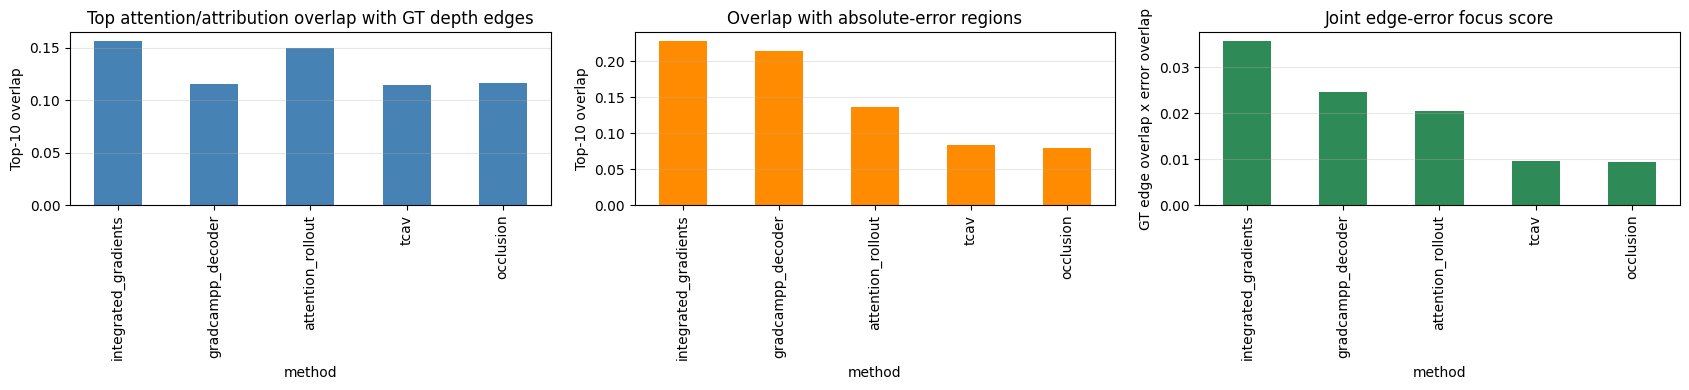

Attention Rollout edge-focus check
GT edge top-10 overlap: 0.150
Absolute-error top-10 overlap: 0.136
GT-edge corr minus RGB-edge corr: 0.090
Interpretation: higher GT-edge overlap than RGB-edge correlation suggests the map is closer to depth-boundary structure than raw texture edges.


In [20]:
# [Notebook Cell]
# Edge/error summaries separate geometric explanations from failure-localization behavior.
def build_edge_error_focus_table(xai_df):
    """Summarize whether each explanation emphasizes geometry, texture, or failure regions."""
    rows = []
    for method, group in xai_df.groupby('method'):
        rows.append({
            'method': method,
            'mean_gt_edge_corr': group['corr_gt_depth_edges'].mean(),
            'mean_pred_edge_corr': group['corr_pred_depth_edges'].mean(),
            'mean_rgb_edge_corr': group['corr_rgb_edges'].mean(),
            'mean_gt_edge_top10_overlap': group['top10_gt_depth_edge_overlap'].mean(),
            'mean_error_top10_overlap': group['top10_error_overlap'].mean(),
            'edge_minus_rgb_corr': group['corr_gt_depth_edges'].mean() - group['corr_rgb_edges'].mean(),
            'edge_error_joint_score': group['top10_gt_depth_edge_overlap'].mean() * group['top10_error_overlap'].mean(),
        })
    return pd.DataFrame(rows).sort_values('edge_error_joint_score', ascending=False)

edge_focus_df = build_edge_error_focus_table(xai_df)
edge_focus_df.to_csv('outputs/tables/edge_error_focus_analysis.csv', index=False)
display(edge_focus_df)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
edge_focus_df.set_index('method')['mean_gt_edge_top10_overlap'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top attention/attribution overlap with GT depth edges')
axes[0].set_ylabel('Top-10 overlap')
edge_focus_df.set_index('method')['mean_error_top10_overlap'].plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Overlap with absolute-error regions')
axes[1].set_ylabel('Top-10 overlap')
edge_focus_df.set_index('method')['edge_error_joint_score'].plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Joint edge-error focus score')
axes[2].set_ylabel('GT edge overlap x error overlap')
for ax in axes:
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/curves/edge_error_focus_analysis.png', dpi=140, bbox_inches='tight')
plt.show()

attention_row = edge_focus_df[edge_focus_df['method'] == 'attention_rollout'].iloc[0]
print('Attention Rollout edge-focus check')
print(f"GT edge top-10 overlap: {attention_row['mean_gt_edge_top10_overlap']:.3f}")
print(f"Absolute-error top-10 overlap: {attention_row['mean_error_top10_overlap']:.3f}")
print(f"GT-edge corr minus RGB-edge corr: {attention_row['edge_minus_rgb_corr']:.3f}")
print('Interpretation: higher GT-edge overlap than RGB-edge correlation suggests the map is closer to depth-boundary structure than raw texture edges.')

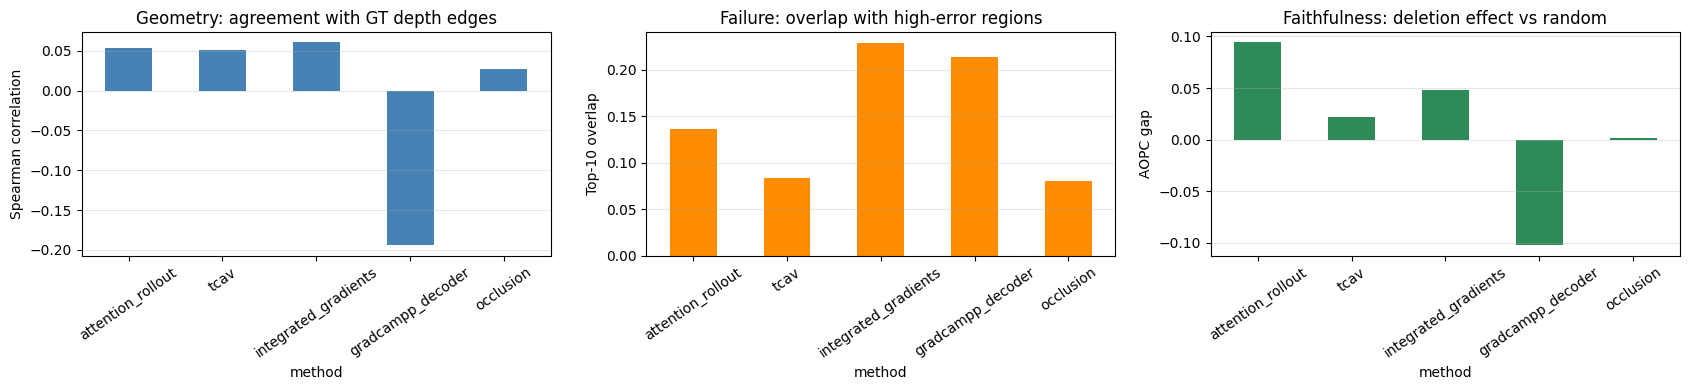

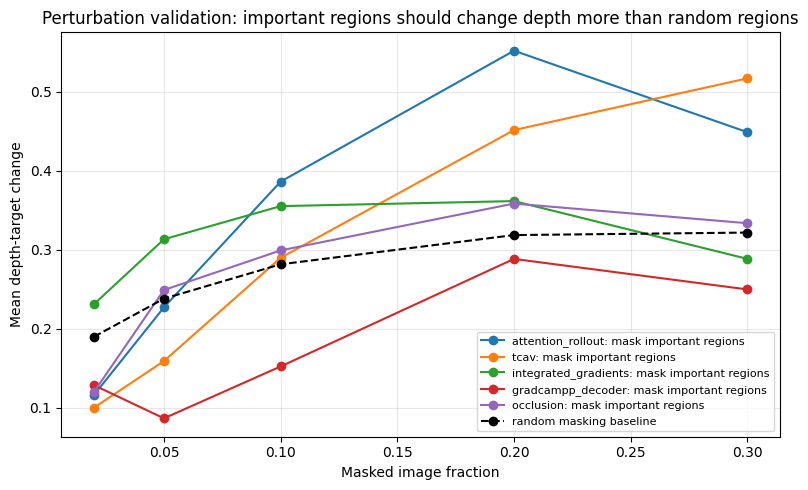

In [21]:
# [Notebook Cell]
# Aggregate plots compare the five XAI methods across geometry, error, and faithfulness axes.
def plot_method_summary(xai_df, perturb_df):
    """Plot method-level averages for geometric alignment, error overlap, and perturbation faithfulness.
    """
    order = ['attention_rollout', 'tcav', 'integrated_gradients', 'gradcampp_decoder', 'occlusion']
    order = [m for m in order if m in set(xai_df['method'])]
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))

    xai_df.groupby('method')['corr_gt_depth_edges'].mean().reindex(order).plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Geometry: agreement with GT depth edges')
    axes[0].set_ylabel('Spearman correlation')

    xai_df.groupby('method')['top10_error_overlap'].mean().reindex(order).plot(kind='bar', ax=axes[1], color='darkorange')
    axes[1].set_title('Failure: overlap with high-error regions')
    axes[1].set_ylabel('Top-10 overlap')

    perturb_df.groupby('method')['aopc_vs_random'].mean().reindex(order).plot(kind='bar', ax=axes[2], color='seagreen')
    axes[2].set_title('Faithfulness: deletion effect vs random')
    axes[2].set_ylabel('AOPC gap')

    for ax in axes:
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=35)
    plt.tight_layout()
    plt.savefig('outputs/curves/method_summary_bars.png', dpi=140, bbox_inches='tight')
    plt.show()

def plot_perturbation_summary(perturb_df):
    """Visualize deletion curves to compare salient-region masking with a random baseline."""
    curve = perturb_df[perturb_df['mask_mode'].isin(['top', 'random'])]
    curve = curve.groupby(['method', 'fraction', 'mask_mode'])['target_delta'].mean().reset_index()

    plt.figure(figsize=(8, 5))
    for method in ['attention_rollout', 'tcav', 'integrated_gradients', 'gradcampp_decoder', 'occlusion']:
        s = curve[(curve['method'] == method) & (curve['mask_mode'] == 'top')]
        if len(s):
            plt.plot(s['fraction'], s['target_delta'], marker='o', label=f'{method}: mask important regions')

    random_baseline = curve[curve['mask_mode'] == 'random'].groupby('fraction')['target_delta'].mean().reset_index()
    if len(random_baseline):
        plt.plot(random_baseline['fraction'], random_baseline['target_delta'], 'k--', marker='o', label='random masking baseline')

    plt.title('Perturbation validation: important regions should change depth more than random regions')
    plt.xlabel('Masked image fraction')
    plt.ylabel('Mean depth-target change')
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig('outputs/curves/perturbation_summary.png', dpi=140, bbox_inches='tight')
    plt.show()

plot_method_summary(xai_df, perturb_df)
plot_perturbation_summary(perturb_df)

def plot_selection_group_gallery(group_name, sample_ids):
    """Create a report-ready matrix with one sample per row and all visual outputs as columns."""
    file_specs = [
        ('rgb.png', 'RGB'), ('gt_depth.png', 'GT depth'), ('predicted_depth.png', 'Prediction'),
        ('absolute_error.png', 'Abs. error'), ('attention_rollout_overlay.png', 'Attention'),
        ('tcav_overlay.png', 'CAV projection'), ('integrated_gradients_overlay.png', 'IG'),
        ('gradcampp_decoder_overlay.png', 'Grad-CAM++'), ('occlusion_overlay.png', 'Occlusion'),
    ]
    images, titles = [], []
    for sample_id in sample_ids:
        for filename, label in file_specs:
            images.append(np.array(Image.open(f'outputs/xai/sample_{sample_id}/{filename}').convert('RGB')))
            titles.append(f'{label}\nsample {sample_id}' if label == 'RGB' else label)
    if images:
        plot_grid(
            images, titles, path=f'outputs/curves/{group_name}_sample_gallery.png',
            cols=len(file_specs), figsize=(24, 3.2 * len(sample_ids)), show=False,
        )

plot_selection_group_gallery('good', good_ids)
plot_selection_group_gallery('random', random_ids)
plot_selection_group_gallery('bad', bad_ids)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
runtime_plot = method_timing_df.groupby('method').agg(runtime_seconds=('runtime_seconds', 'mean'), peak_cuda_memory_gb=('peak_cuda_memory_gb', 'max'))
runtime_plot['runtime_seconds'].sort_values().plot(kind='barh', ax=axes[0], color='slateblue')
axes[0].set_title('Mean explanation runtime per image')
axes[0].set_xlabel('Seconds')
runtime_plot['peak_cuda_memory_gb'].sort_values().plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Peak allocated CUDA memory')
axes[1].set_xlabel('GB')
for ax in axes:
    ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.savefig('outputs/curves/runtime_resource_summary.png', dpi=160, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric, title in zip(axes, ['rmse', 'abs_rel', 'd1'], ['RMSE', 'AbsRel', 'delta1 accuracy']):
    pred_df.boxplot(column=metric, by='selection_group', ax=ax, grid=False)
    ax.set_title(title)
    ax.set_xlabel('Selection group')
    ax.grid(axis='y', alpha=0.25)
fig.suptitle('Prediction quality across explained sample groups')
plt.tight_layout()
plt.savefig('outputs/curves/prediction_group_comparison.png', dpi=160, bbox_inches='tight')
plt.show()


## 17. Randomization Sanity Check

This checks whether explanations depend on the trained model parameters.

The table reports how much predictions changed after randomization and how similar the explanation maps stayed. A stronger sanity result means the prediction changes and the explanation changes with it.

If an explanation remains very similar after model randomization, interpret that method cautiously.


integrated gradients:   0%|          | 0/4 [00:00<?, ?it/s]

Randomization: decoder


integrated gradients:   0%|          | 0/4 [00:00<?, ?it/s]

Grad-CAM++ layers:
  encoder_last encoder_last tokens
  decoder_preferred depth_head.scratch.refinenet1.resConfUnit2.skip_add.activation_post_process (1, 64, 148, 148)
Randomization: encoder_last4


integrated gradients:   0%|          | 0/4 [00:00<?, ?it/s]

Grad-CAM++ layers:
  encoder_last encoder_last tokens
  decoder_preferred depth_head.scratch.refinenet1.resConfUnit2.skip_add.activation_post_process (1, 64, 148, 148)
Randomization: full


integrated gradients:   0%|          | 0/4 [00:00<?, ?it/s]

Grad-CAM++ layers:
  encoder_last encoder_last tokens
  decoder_preferred depth_head.scratch.refinenet1.resConfUnit2.skip_add.activation_post_process (1, 64, 148, 148)


,randomization_level,method,pred_mae,pred_rmse,pred_corr_spearman,explanation_spearman,explanation_top10_overlap
0,decoder,integrated_gradients,2.703384,2.875601,0.057333,0.820684,0.518970
1,decoder,gradcampp_decoder,2.703384,2.875601,0.057333,-0.245198,0.010957
2,encoder_last4,integrated_gradients,1.752445,1.987117,0.368371,0.822174,0.533318
3,encoder_last4,gradcampp_decoder,1.752445,1.987117,0.368371,0.494620,0.396579
4,full,integrated_gradients,2.769190,2.937816,0.000000,0.000000,0.132938
5,full,gradcampp_decoder,2.769190,2.937816,0.000000,0.000000,0.206731


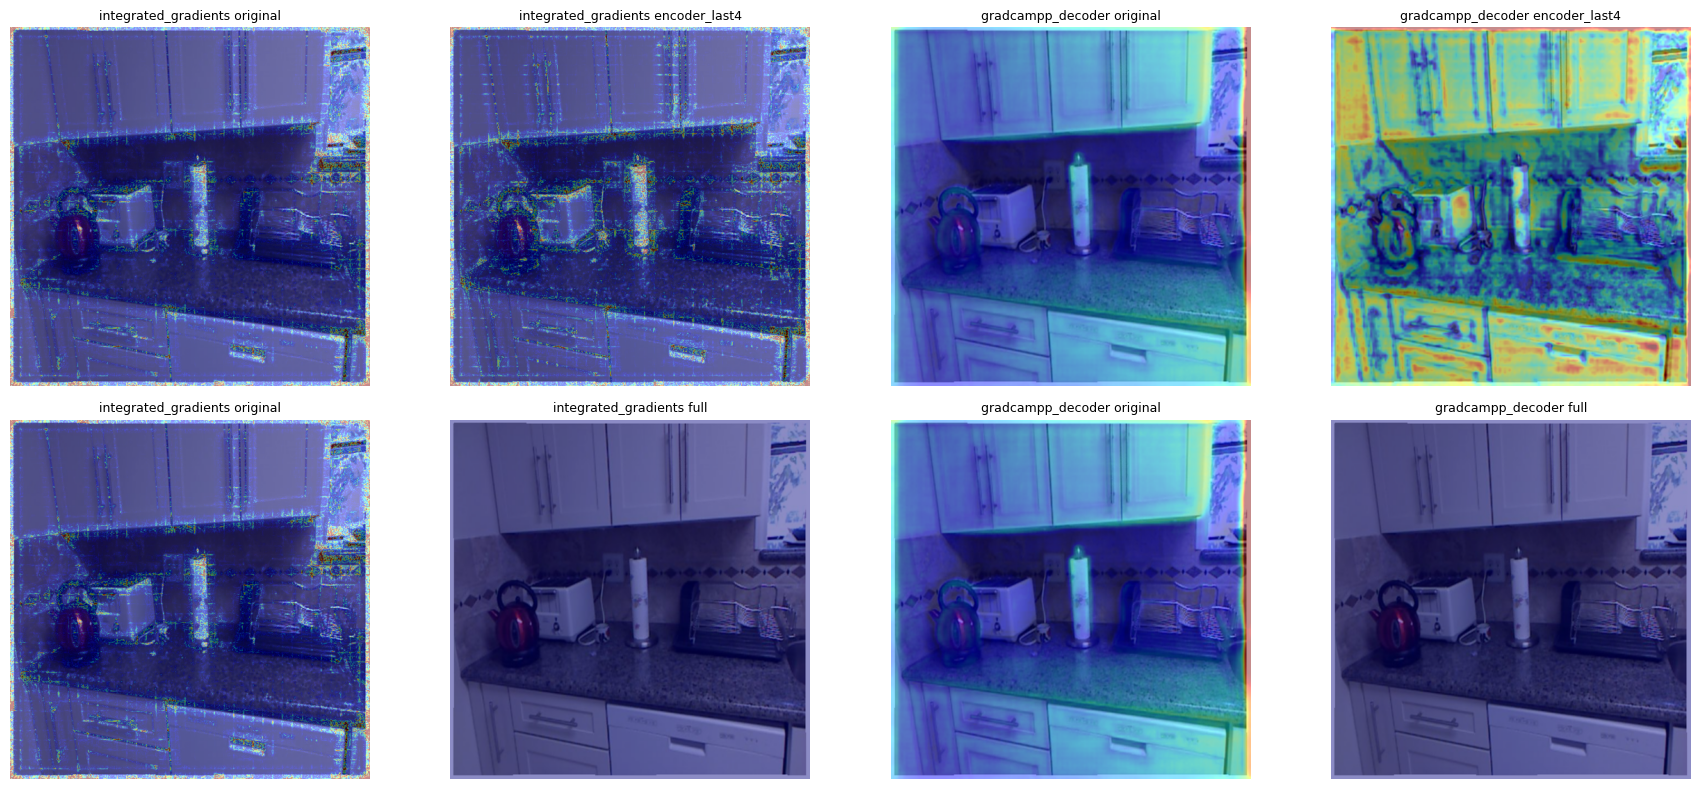

In [22]:
# [Notebook Cell]
# Randomization sanity checks verify that explanations respond to parameter corruption, not just image priors.
def randomize_module_parameters(module):
    """Reset module parameters recursively for saliency randomization sanity checks."""
    for m in module.modules():
        if hasattr(m, 'reset_parameters'):
            m.reset_parameters()

def randomize_last_encoder_blocks(active_model, n=4):
    """Corrupt the final ViT blocks to test whether explanations depend on late encoder semantics.
    """
    blocks = getattr(getattr(active_model, 'pretrained', None), 'blocks', None)
    if blocks is not None:
        for block in blocks[-n:]:
            randomize_module_parameters(block)

# Randomization levels progressively corrupt decoder-only, late-encoder, then full-network parameters.
def build_randomized_copy(level):
    """Create a checkpoint-initialized model copy with controlled parameter randomization."""
    copied = DepthAnythingV2(**MODEL_CONFIGS[MODEL_ENCODER])
    copied.load_state_dict(torch.load(ckpt_path, map_location='cpu'))
    copied = copied.to(DEVICE).eval()
    if level == 'decoder':
        for attr in ['scratch', 'depth_head', 'head']:
            if hasattr(copied, attr):
                randomize_module_parameters(getattr(copied, attr))
    elif level == 'encoder_last4':
        randomize_last_encoder_blocks(copied, 4)
    elif level == 'full':
        randomize_module_parameters(copied)
    else:
        raise ValueError(level)
    return copied

@torch.no_grad()
def prediction_difference(a, b, image_tensor):
    """Quantify prediction drift between original and randomized models on one image."""
    p0, p1 = predict_depth(image_tensor, a), predict_depth(image_tensor, b)
    return {
        'pred_mae': float((p0 - p1).abs().mean().cpu()),
        'pred_rmse': float(torch.sqrt(((p0 - p1) ** 2).mean()).cpu()),
        'pred_corr_spearman': safe_corr(p0[0].cpu().numpy(), p1[0].cpu().numpy()),
    }

def compute_sanity_maps(active_model, image_tensor, target):
    """Recompute lightweight explanations after randomization for saliency similarity tests."""
    maps = {}
    # Use fewer steps for sanity checks to save memory/time
    sanity_steps = max(2, IG_STEPS // 4)
    if 'integrated_gradients' in SANITY_METHODS:
        maps['integrated_gradients'] = integrated_gradients(active_model, image_tensor, target, steps=sanity_steps)
    if 'gradcampp_decoder' in SANITY_METHODS:
        maps['gradcampp_decoder'], _ = gradcampp_map(active_model, image_tensor, target, 'decoder_preferred')
    return maps

if RUN_RANDOMIZATION_SANITY and len(selected_pairs):
    sanity_pair = selected_pairs[0]
    item = predict_pair(sanity_pair)
    target = DenseDepthTarget('global_mean')

    # Compute original maps once
    original_maps = compute_sanity_maps(model, item['x'], target)

    rows = []
    panels, titles = [], []
    rgb = np.array(item['image_pil'].resize((INPUT_SIZE, INPUT_SIZE)))

    for level in RANDOMIZATION_LEVELS:
        print('Randomization:', level)
        randomized = build_randomized_copy(level)

        pred_delta = prediction_difference(model, randomized, item['x'])
        randomized_maps = compute_sanity_maps(randomized, item['x'], target)

        for method, original_hm in original_maps.items():
            rows.append({
                'randomization_level': level,
                'method': method,
                **pred_delta,
                'explanation_spearman': safe_corr(original_hm, randomized_maps[method]),
                'explanation_top10_overlap': topk_overlap(original_hm, randomized_maps[method]),
            })

        if level in ['encoder_last4', 'full']:
            for method in original_maps:
                panels += [overlay_heatmap(rgb, original_maps[method]), overlay_heatmap(rgb, randomized_maps[method])]
                titles += [f'{method} original', f'{method} {level}']

        # Cleanup randomized model immediately to prevent OOM
        del randomized
        gc.collect()
        torch.cuda.empty_cache()

    sanity_df = pd.DataFrame(rows)
    sanity_df.to_csv('outputs/tables/randomization_sanity.csv', index=False)
    display(sanity_df)
    if panels:
        plot_grid(panels, titles, path='outputs/xai/randomization_sanity.png', cols=4, figsize=(18, 8))
else:
    print('Randomization sanity skipped.')

## 18. Final Output Check

This cell displays the key pairwise images for the best and worst selected samples. It is only a visual inspection step; it does not recompute XAI.

Start by looking at these pairs:

- GT depth vs predicted depth
- predicted depth vs absolute error
- Attention Rollout vs absolute error
- Integrated Gradients vs absolute error
- TCAV vs absolute error
- Attention Rollout vs Integrated Gradients

These are the figures to inspect first before reading the larger metric tables.


Existing key outputs:
 - outputs/xai/sample_873/01_gt_vs_prediction.png
 - outputs/xai/sample_873/02_prediction_vs_error.png
 - outputs/xai/sample_873/03_attention_vs_error.png
 - outputs/xai/sample_873/04_ig_vs_error.png
 - outputs/xai/sample_873/08_tcav_vs_error.png
 - outputs/xai/sample_873/07_attention_vs_ig.png
 - outputs/xai/sample_800/01_gt_vs_prediction.png
 - outputs/xai/sample_800/02_prediction_vs_error.png
 - outputs/xai/sample_800/03_attention_vs_error.png
 - outputs/xai/sample_800/04_ig_vs_error.png
 - outputs/xai/sample_800/08_tcav_vs_error.png
 - outputs/xai/sample_800/07_attention_vs_ig.png
 - outputs/curves/method_summary_bars.png
 - outputs/curves/edge_error_focus_analysis.png
 - outputs/curves/perturbation_summary.png
 - outputs/xai/randomization_sanity.png


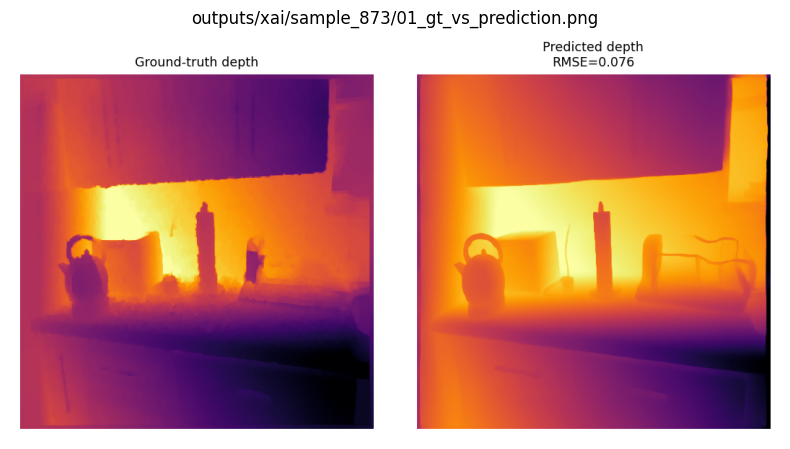

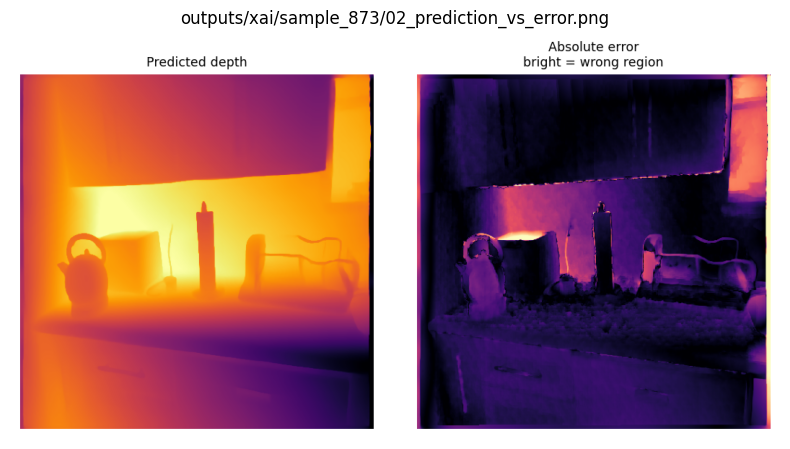

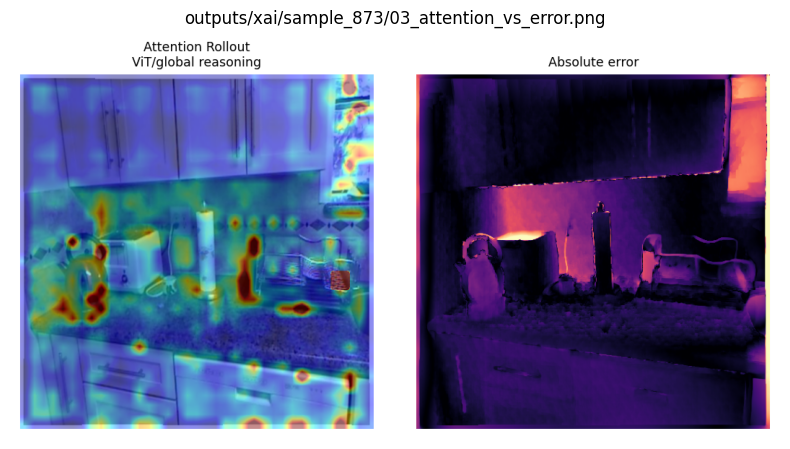

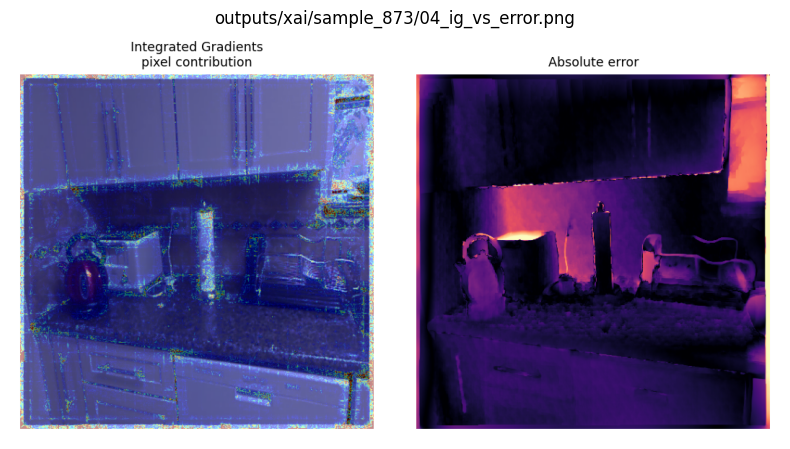

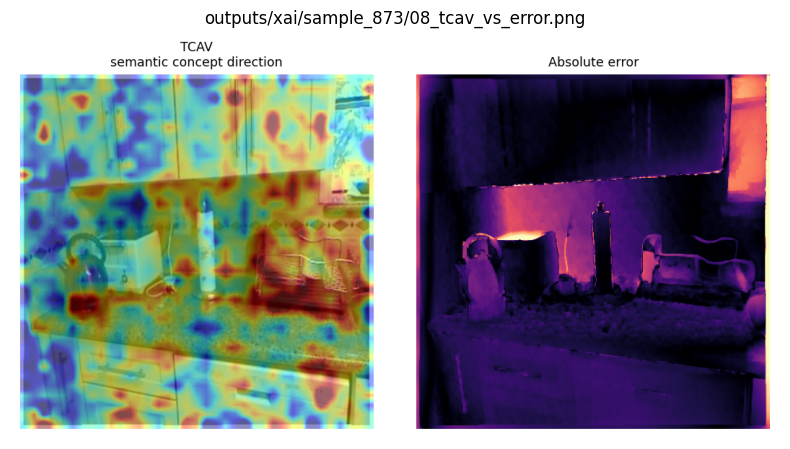

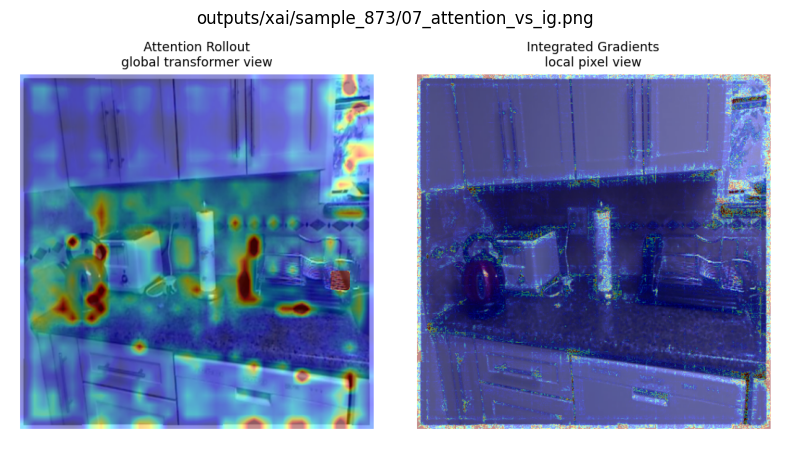

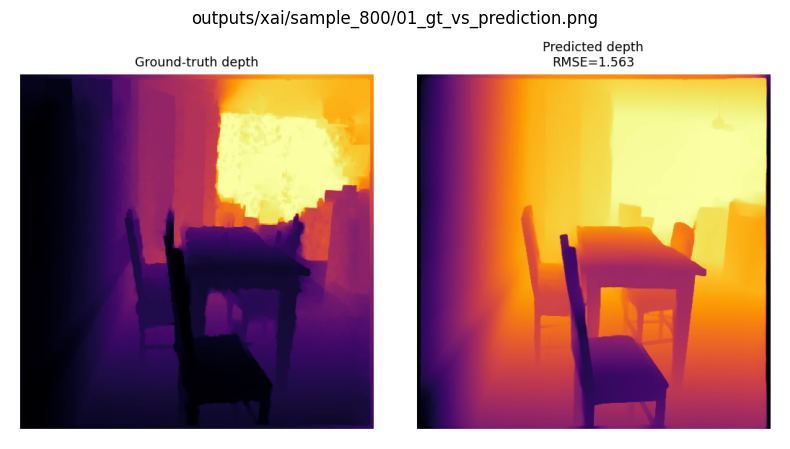

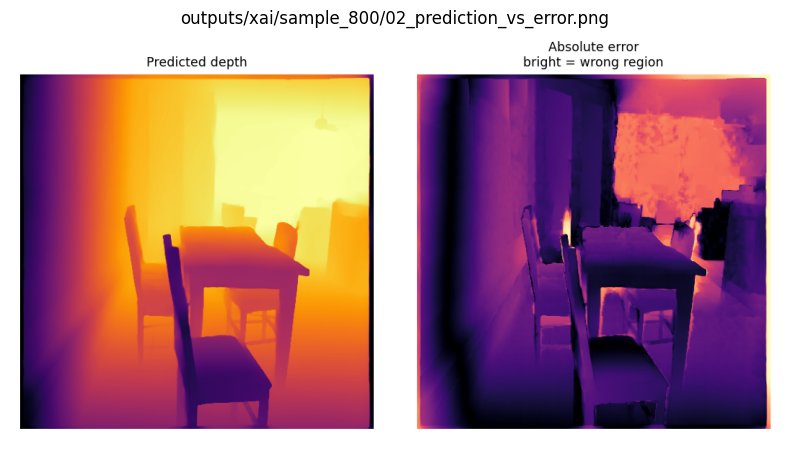

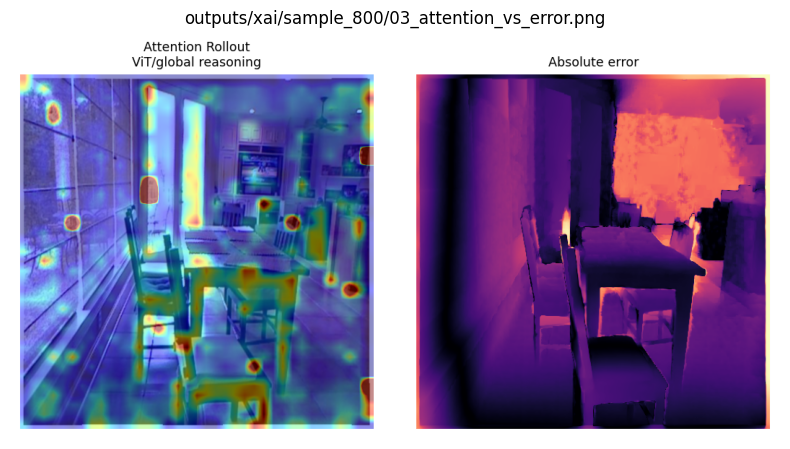

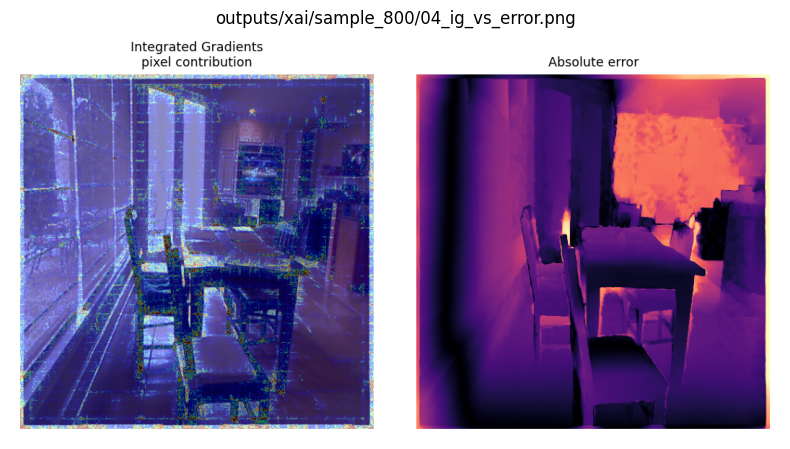

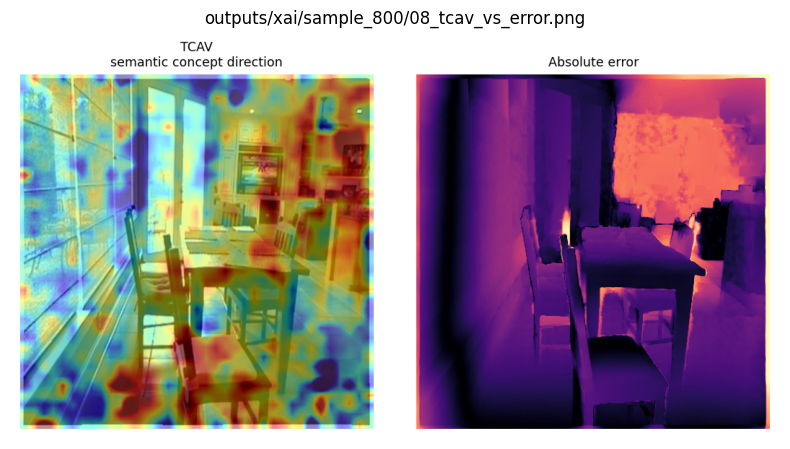

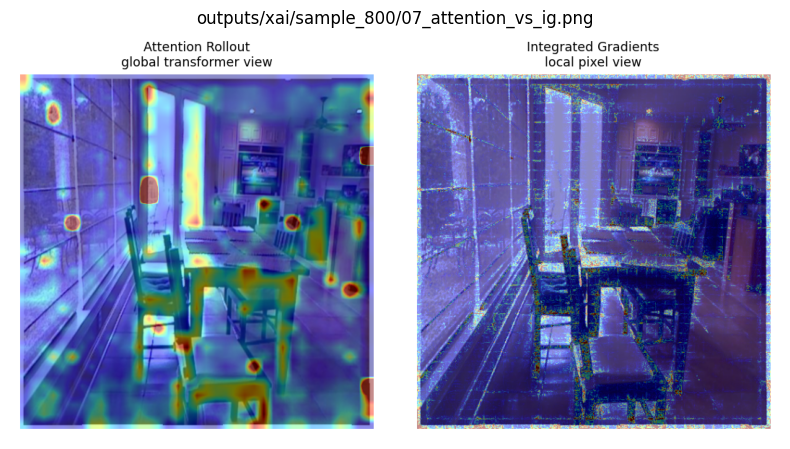

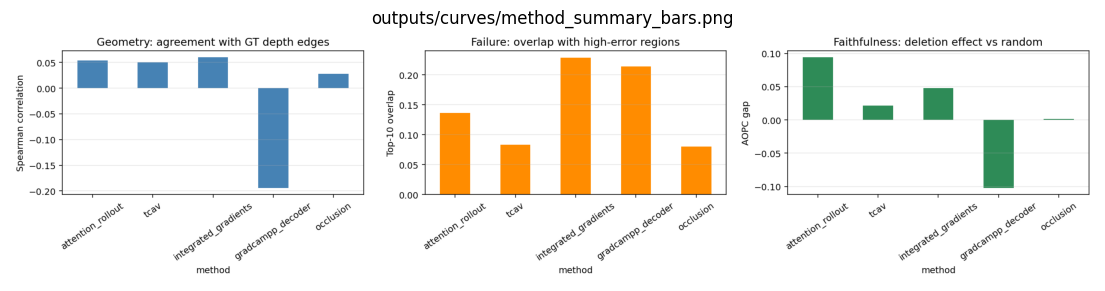

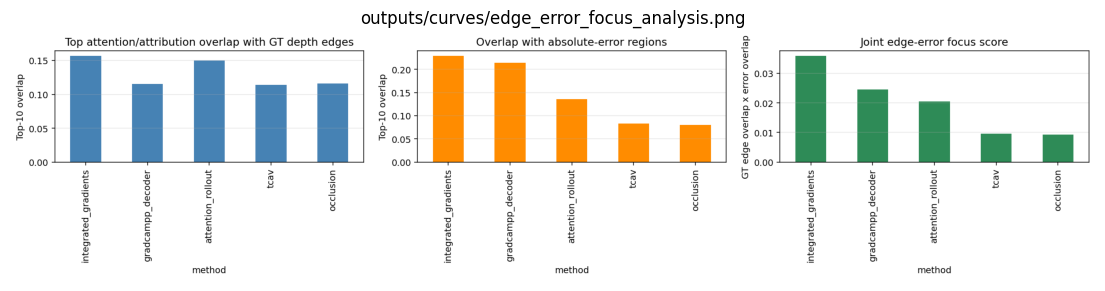

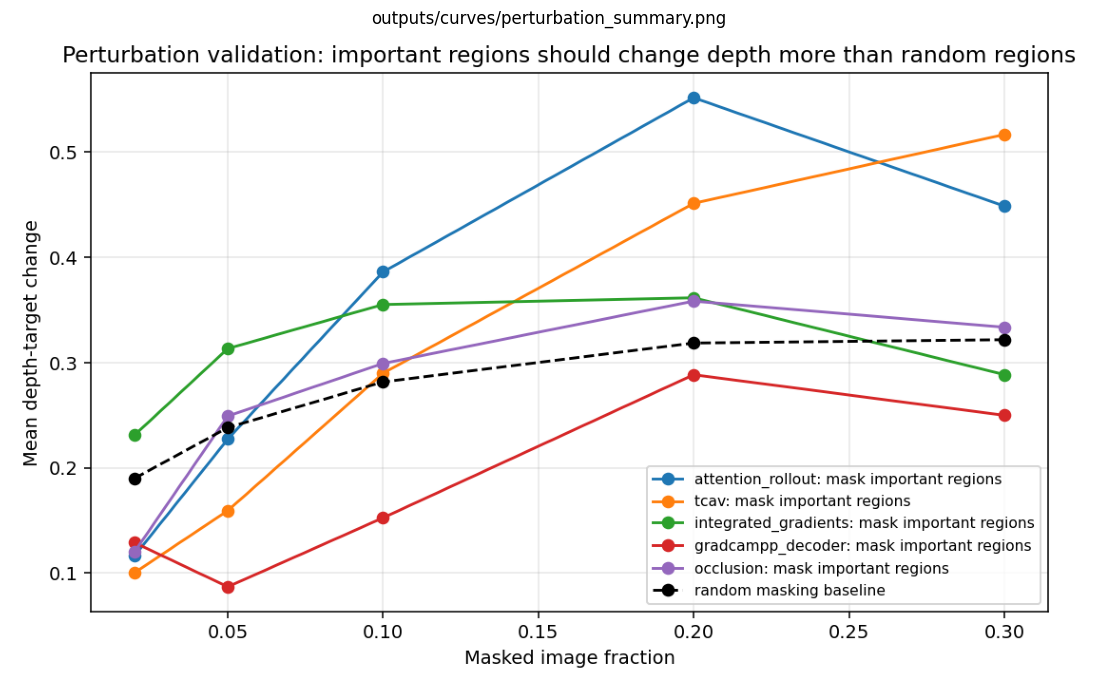

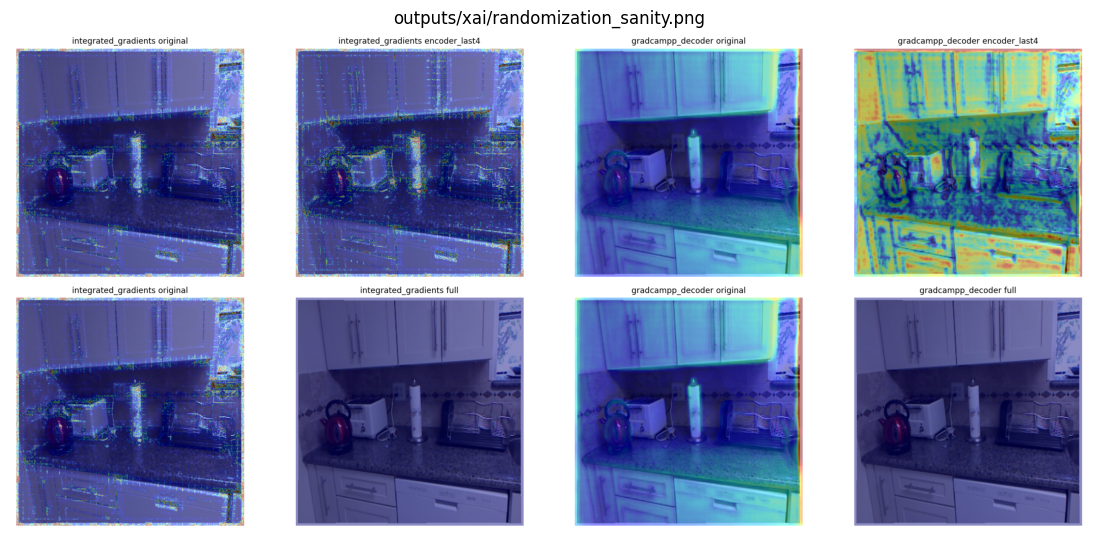

In [23]:
# [Notebook Cell]
# Final inspection gathers representative saved figures without recomputing expensive XAI maps.
from pathlib import Path

pairwise_files = [
    '01_gt_vs_prediction.png',
    '02_prediction_vs_error.png',
    '03_attention_vs_error.png',
    '04_ig_vs_error.png',
    '08_tcav_vs_error.png',
    '07_attention_vs_ig.png',
]

comparison_paths = []
if 'pred_df' in globals() and len(pred_df):
    best_id = int(pred_df.sort_values('rmse').iloc[0]['id'])
    worst_id = int(pred_df.sort_values('rmse').iloc[-1]['id'])
    for sample_id in [best_id, worst_id]:
        comparison_paths.extend([f'outputs/xai/sample_{sample_id}/{name}' for name in pairwise_files])
    representative_ids = [best_id] + ([int(random_ids[0])] if random_ids else []) + [worst_id]
    comparison_paths.extend([f'outputs/xai/sample_{sample_id}/00_full_visual_summary.png' for sample_id in representative_ids])
else:
    sample_dirs = sorted(Path('outputs/xai').glob('sample_*'))[:2]
    for sample_dir in sample_dirs:
        comparison_paths.extend([str(sample_dir / name) for name in pairwise_files])

summary_paths = [
    'outputs/curves/method_summary_bars.png',
    'outputs/curves/edge_error_focus_analysis.png',
    'outputs/curves/perturbation_summary.png',
    'outputs/curves/prediction_quality_distribution.png',
    'outputs/curves/prediction_group_comparison.png',
    'outputs/curves/runtime_resource_summary.png',
    'outputs/curves/good_sample_gallery.png',
    'outputs/curves/random_sample_gallery.png',
    'outputs/curves/bad_sample_gallery.png',
    'outputs/xai/randomization_sanity.png',
]

key_output_paths = comparison_paths + summary_paths
existing = [Path(p) for p in key_output_paths if Path(p).exists()]
missing = [p for p in key_output_paths if not Path(p).exists()]

print('Existing key outputs:')
for p in existing:
    print(' -', p)

if missing:
    print('\nMissing outputs. This is normal if the full XAI cells above have not run yet:')
    for p in missing:
        print(' -', p)

for p in existing:
    img = Image.open(p).convert('RGB')
    width, height = img.size
    fig_w = 10 if 'sample_' in str(p) else 14
    fig_h = max(3.5, fig_w * height / width)
    plt.figure(figsize=(fig_w, fig_h))
    plt.imshow(img)
    plt.axis('off')
    plt.title(str(p))
    plt.show()


## 19. References

- Depth Anything V2, 2024.
- DINOv2: Learning Robust Visual Features without Supervision, 2023.
- Attention Rollout / Attention Flow, Abnar and Zuidema, 2020.
- Integrated Gradients, Sundararajan et al., 2017.
- Testing with Concept Activation Vectors, Kim et al., 2018.
- Grad-CAM++, Chattopadhyay et al., 2018.
- Sanity Checks for Saliency Maps, Adebayo et al., 2018.
- Vision Transformers for Dense Prediction, Ranftl et al., 2021.


## 20. Download Outputs

This cell zips the generated `outputs/` folder so the notebook results can be downloaded from Colab.


In [24]:
# [Notebook Cell]
# Packaging outputs makes Colab artifacts downloadable for report writing and submission.
try:
    from google.colab import files
    selected_output_files = []
    selected_output_files.extend(Path('outputs/tables').glob('*'))
    selected_output_files.extend(Path('outputs/curves').glob('*'))
    sanity_figure = Path('outputs/xai/randomization_sanity.png')
    if sanity_figure.exists():
        selected_output_files.append(sanity_figure)
    for sample_id in selected_ids:
        selected_output_files.extend(Path(f'outputs/xai/sample_{sample_id}').glob('*'))
    selected_output_files = sorted({p for p in selected_output_files if p.is_file() and p.name != 'output_inventory.csv'})

    inventory_df = pd.DataFrame([
        {'path': str(path.relative_to('outputs')), 'size_bytes': path.stat().st_size}
        for path in selected_output_files
    ])
    inventory_path = Path('outputs/tables/output_inventory.csv')
    inventory_df.to_csv(inventory_path, index=False)
    selected_output_files.append(inventory_path)

    archive_path = Path('depth_anything_v2_xai_outputs.zip')
    with zipfile.ZipFile(archive_path, 'w', compression=zipfile.ZIP_DEFLATED, compresslevel=6) as archive:
        for path in selected_output_files:
            archive.write(path, arcname=path.relative_to('outputs'))
    size_mb = os.path.getsize('depth_anything_v2_xai_outputs.zip') / 1e6
    print(f'Downloading depth_anything_v2_xai_outputs.zip ({size_mb:.1f} MB, checkpoint excluded)')
    files.download('depth_anything_v2_xai_outputs.zip')
except Exception as exc:
    print('Download skipped outside Colab:', repr(exc))
    print('Outputs are in ./outputs')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>